In [169]:
"""
LDA PIPELINE -- ALL-SESSIONS VARIANT
====================================
A copy of LDA_analyses_pipeline_CORRECTED with two changes, both about WHICH
sessions define things. Everything else is identical.

1. BALANCED SUBSAMPLING KEEPS EVERY MOUSE (cells with `balanced_idx`).
   The original rule was
       if len(m_idx) >= cap: rng.choice(m_idx, cap)
   which dropped a mouse with fewer sessions than the cap out of the TRAINING set
   while still TESTING it -- against a classifier that had never seen it, so those
   folds were guaranteed misses. Because the guard is evaluated after leave-one-out,
   a mouse fell below it precisely in the folds where it was the test item. With 20
   of 58 mice having exactly 3 sessions, n_per_mouse=4 turned 22% of folds into
   automatic errors and accuracy dropped for that reason alone. The cap is now a
   maximum contribution rather than a minimum requirement:
       take = min(cap, len(m_idx))
   Measured effect: n_per_mouse 3 / 4 / 5 gives 0.770 / 0.651 / 0.480 under the old
   rule and 0.770 / 0.814 / 0.848 under this one -- monotone, as expected.

   THE CAP IS NOW n_per_mouse ITSELF, not n_per_mouse - 1. The -1 only ever existed to
   guarantee that every mouse could meet the cap under the broken guard; `take = min(...)`
   makes it redundant, and it had left the scoring cell capping at 2 while the embedding
   cells capped at 3. Consequence: the score this notebook reports RISES (cap 2 -> 3 is
   roughly the 0.758 -> 0.849 step in the table above). That is a change of definition,
   not a bug fix, so any previously quoted number has to be re-quoted.

2. THE SAVED EMBEDDING IS FIT ON ALL SESSIONS (the `final_transformed` cell).
   It used to be fit on whatever X_train the loop above happened to leave behind --
   one arbitrary balanced draw from the last fold. That made the saved embedding
   irreproducible: two draws under the same rule give LD1 axes correlating anywhere
   from 0.05 to 0.85, because the leading LDA eigenvalues are near-degenerate
   (0.267 vs 0.253) and each draw picks a different rotation within the same
   subspace. Fitting on every session is deterministic (two refits give |rho| = 1.0).

   KNOWN LIMITATION of change 2: sessions per mouse are unequal (3 to 16), so mice
   with more sessions weigh more in the pooled within-class scatter, and mice with
   fewer get noisier -- therefore more extreme -- class means. Set EMBED_BALANCED to
   True to fit the embedding on one balanced draw per mouse instead (reproducible via
   EMBED_SEED, but back to depending on a draw).
"""
EMBED_BALANCED = False     # False = fit the embedding on all sessions
EMBED_SEED = 0             # only used when EMBED_BALANCED is True

# =============================================================================
# DATA FILTERING -- every "which data goes in" decision, in one place
# =============================================================================
# These four knobs are the only places that decide what the pipeline sees. They are
# applied in filter_sequences (sessions, mice) and build_design_matrix (trials), so
# changing them here changes every cell below at once.
#
# WHY THIS EXISTS. The syllable file is ~1% missing overall, but the loss is concentrated
# in a couple of animals: CSH_ZAD_026 loses 10-21% of its bins and NYU-30 32-54%. Traced
# back, both are RIGHT-PAW tracking dropouts -- 97% and 91% of their missing states are
# frames where r_paw_x/r_paw_y are NaN and every other signal is present. The paw HMM is
# fit on both paws, so a right-paw dropout costs the whole syllable even though whisking
# and licking were measured fine. NYU-30's three sessions are exactly the ones the QC
# sheet marks 'need to revise' ("right paw might be occluded?", video QC FAIL both sides).
#
# WHAT IT COSTS TO FILTER (measured, refit each time; LD1's sign is arbitrary):
#   nothing dropped                269 sessions  58 mice  LOO 0.848    --
#   DROP_INCOMPLETE_TRIALS=True    269 sessions  58 mice  LOO 0.838   |r| LD1 vs ref 0.994
#   MAX_SESSION_MISSING=0.05       259 sessions  56 mice  LOO 0.859   |r| 0.817
#   QC 'filtered_out_and_revise'   263 sessions  57 mice  LOO 0.852   |r| 0.909
# The axis is insensitive to the missing data itself (the trial-level test is the direct
# one: |r| = 0.994). The session/mouse filters move it more only because they remove
# whole ANIMALS, and the animals they remove are extreme -- dropping two equally extreme
# but well-tracked mice perturbs LD1 just as much (|r| 0.74-0.91). So filtering is about
# what you are willing to call behaviour, not about rescuing the axis.

QC_STRICTNESS = 'filtered_out'
# Which sessions the curated QC sheet removes (session_filters.exclusions_by_timepoint):
#   'filtered_out'            -> 'Used in paper' == 'filtered out'         (12 sessions)
#   'filtered_out_and_revise' -> those PLUS 'need to revise'               (21 sessions)
# The stricter setting is the principled way to lose NYU-30: it is a curated judgement
# rather than a threshold chosen after seeing the result.

MAX_SESSION_MISSING = None
# Drop sessions with more than this fraction of NaN bins. None = keep every session.
# Measured over the 269 sessions that reach the LDA -- note how fast this bites, because
# the 3-session minimum takes whole mice down with the sessions:
#   > 20%  ->  4 sessions,  1 mouse lost (NYU-30)                   ->  4 sessions gone
#   > 10%  ->  8 sessions,  2 mice lost (+ CSH_ZAD_026)             ->  9 sessions gone
#   >  5%  ->  9 sessions,  2 mice lost                             -> 10 sessions gone
#   >  2%  -> 19 sessions,  4 mice lost (+ NYU-48, ibl_witten_27)   -> 23 sessions gone
#   >  1%  -> 24 sessions,  5 mice lost (+ NYU-39)                  -> 27 sessions gone
#   > 0.5% -> 29 sessions,  7 mice lost                             -> 36 sessions gone
# The median session is at 0.00% and the 90th percentile at 0.7%, so anything below ~1%
# stops screening artifacts and starts screening ordinary sessions: at 1% you would lose
# 5 mice, 3 of which are not flagged by any QC criterion.

DROP_INCOMPLETE_TRIALS = False
# Trial-level screen: drop any trial with a missing bin anywhere in its four epochs,
# instead of letting the per-session mean skip the missing bins. This is the honest test
# of whether missing data biases the features, because it changes nothing else -- no mouse
# and no session leaves. It costs CSH_ZAD_026 ~75% of its trials and NYU-30 ~85% and still
# reproduces the axis at |r| = 0.994, which is why the missing data is not treated as a
# threat to LD1 anywhere below.

MIN_SESSIONS_PER_MOUSE = 3
# A mouse needs at least this many surviving sessions to stay a class. Was hardcoded as
# `session_count > 2` inside filter_sequences. It is applied AFTER the other screens, so
# raising MAX_SESSION_MISSING can remove a mouse without naming it -- filter_sequences
# now prints which mice go and why.

# =============================================================================
# LAB VARIANCE
# =============================================================================
# =============================================================================
# WHICH SYLLABLE CHANNELS GO INTO THE LDA
# =============================================================================
SYLLABLE_CHANNELS = ('paw', 'whisk', 'lick')      # any subset, e.g. ('paw',)
# SYLLABLE_CHANNELS = ('paw', 'whisk')      # any subset, e.g. ('paw',)
# SYLLABLE_CHANNELS = ('paw',)      # any subset, e.g. ('paw',)
# A syllable is (paw state, whisking on/off, licking on/off). binarize() lays each
# timestep out as 7 paw one-hot columns (paw state 1 is the dropped reference) + whisk +
# lick = 9, so a channel is a clean column subset and nothing else in the pipeline changes.
#
# WHY YOU MIGHT DROP CHANNELS. Measured on these 269 sessions -- lab share of variance from
# the nested partition, mouse identification leave-one-session-out, and lab decoded from a
# HELD-OUT MOUSE (chance 0.017 and 0.100):
#
#   channels             feat    lab    mouse   p        mouse ID   lab
#   paw + whisk + lick    360   0.166   0.490   <0.001     0.848    0.398
#   paw + whisk           320   0.114   0.526   <0.001     0.794    0.297
#   paw only              280   0.042   0.505    0.111     0.736    0.234
#   whisk only             40   0.208   0.554   <0.001     0.513    0.338
#   lick only              40   0.345   0.366   <0.001     0.435    0.375
#
# PAW ONLY IS THE ONLY SUBSET WITH NO DETECTABLE LAB EFFECT (p = 0.111) and it still
# identifies the mouse at 0.736 of 58. Lick costs 5 points of identification and buys back
# 10 points of lab leakage; it is also the channel the QC sheet flags separately
# (lick_detection, "bad lick fit"). The same ranking appears in the RAW video signals
# (Lick count 0.338 lab, whisker_me 0.166, paw velocities 0.030-0.167), so it is a property
# of the signals, not of the HMM discretisation.
#
# WHAT IT COSTS: the axis changes. This is a different feature space, so LD1 from a
# paw-only run is not the LD1 the rest of the paper quotes -- refit and re-check any
# correlate you carry over, and say which channels were used.

# =============================================================================
# SPLIT THE FEATURE VECTOR BY TRIAL TYPE
# =============================================================================
TRIAL_TYPE_SPLIT = None
# None -> one block of (bins x channels) per session, averaged over ALL its trials. This
#         is the original behaviour and nothing below changes.
# Otherwise -> the SAME block is computed SEPARATELY within each level of the split and the
#         blocks are laid side by side, so a session row becomes
#             [level 1: 40 bins x channels][level 2: 40 bins x channels] ...
#         and the LDA sees how a mouse behaves in each condition rather than only its
#         average. The feature count multiplies by the number of levels: 360 -> 720 for
#         correct vs incorrect with all three channels.
#
# `trial_type` in the syllable file is the compound string that functions.define_trial_types
# builds from trial_type_agg = ['correct_str', 'contrast_str', 'block_str', 'choice'],
# e.g. 'correct 0.25 0.8 right'. Name the field(s) to split on:
#     'feedback'   correct / incorrect
#     'contrast'   0.0 / 0.0625 / 0.125 / 0.25 / 1.0
#     'block'      0.2 / 0.5 / 0.8   (the biased blocks; 0.5 is the unbiased opening block)
#     'side'       left / right / no_go
# A tuple crosses fields -- ('feedback', 'block') gives 6 blocks and 2160 features. A
# callable receives the raw trial_type string and returns a label, or None to drop the
# trial, for splits that are not a plain field:
#     TRIAL_TYPE_SPLIT = lambda t: 'easy' if t.split(' ')[1] in ('1.0', '0.25') else 'hard'
#
# WHAT IT COSTS. Every level multiplies the columns but not the rows: 269 sessions x 720
# features for a two-way split, where the unsplit matrix is 269 x 360. PCA absorbs that
# (min_components is unchanged), but the blocks are strongly correlated with each other --
# a mouse that whisks a lot whisks a lot in both conditions -- so the extra columns buy
# mostly the DIFFERENCE between conditions, which is the smaller and noisier part. Read the
# LOO score against the unsplit run before concluding the split helped.

TRIAL_TYPE_LEVELS = None
# None = every level present in the data, sorted, which fixes the column order. Or give an
# explicit tuple to both CHOOSE and ORDER the blocks; trials outside it are dropped. This is
# what 'side' needs: no_go appears in 125 of 332 sessions and never more than 9 times in
# one, so use TRIAL_TYPE_LEVELS = ('left', 'right').

TRIAL_TYPE_MIN_TRIALS = 25
# A (session, level) cell built from fewer trials than this counts as MISSING rather than
# being averaged. A 3-trial mean of a binary syllable indicator is mostly sampling noise and
# would enter the LDA looking exactly as solid as a 500-trial mean. Measured cell sizes over
# the 332 sessions in the file:
#     feedback   correct 264-1386 (median 471)   incorrect 26-261 (median 106)
#     block      0.2 112-652      0.5 71-90      0.8 111-781
#     side       left 64-727      right 93-833   no_go 0-9
# so feedback and block clear 20 in every session and the knob only bites for finer splits.

TRIAL_TYPE_ON_MISSING = 'drop_session'
# What happens to a session that cannot fill every block:
#   'drop_session' -- drop the session. The only option under which column j means the same
#                     thing in every row. MIN_SESSIONS_PER_MOUSE is re-applied afterwards,
#                     so a mouse can leave along with its sessions -- the printout says so.
#   'pool'         -- fill the empty cell with that session's mean over all its kept trials.
#                     Keeps the session, but that block then reports the mouse's AVERAGE
#                     behaviour while the same block in other rows reports its behaviour in
#                     the condition, and nothing downstream can tell those rows apart. Use it
#                     only as a check that a result is not carried by which sessions the
#                     strict setting removed.

LAB_CORRECTION = 'none'      # 'none' | 'center' | 'zscore'
# Applied to the session x feature matrix before PCA (the `all_features` cell), by
# functions.remove_lab_variance:
#   'center'  subtract each lab's mean feature vector
#   'zscore'  subtract the lab mean AND divide by the lab's SD across its sessions, so
#             per-lab scale goes too, not only per-lab level
# The lab mean is the mean of the lab's PER-MOUSE means, not of its sessions: session
# counts inside a lab run 3 to 16, and a session-weighted mean would be dominated by the
# busiest animal, so centring would subtract mostly that one mouse from its lab-mates.
# Labs are read offline from the QC sheet's rig_name (10 labs here, 3 to 9 mice each);
# no mouse spans two labs.
#
# READ THIS BEFORE TURNING IT ON. Lab is NESTED INSIDE MOUSE -- every mouse belongs to
# exactly one lab -- so this is not a nuisance regressor that leaves the signal intact.
# After centring, the corrected mouse means within a lab sum to zero, so mouse identity
# loses one dimension per lab: 10 of the 57 discriminant dimensions. The loss is uneven,
# because it is one dimension per lab regardless of size -- a 3-mouse lab gives up 1 of
# its 2 between-mouse dimensions, a 9-mouse lab 1 of 8. Expect the LDA score to fall, and
# expect it to fall further for mice in small labs; that drop is the correction working,
# not a bug, but it is also not separable from "lab differences ARE part of what makes
# these mice different" (rig, camera placement, handling, water schedule).
#
# So the honest use is a COMPARISON, not a replacement: run 'none' and 'center' and report
# both. What survives the correction is individuality that is not explained by lab; what
# does not survive is either lab nuisance or lab-linked individuality, and this design
# cannot tell those apart.


# ---- FEATURE NORMALISATION --------------------------------------------------------
FEATURE_NORM = None       # None | 'global' | 'per_lab'
# Rank-based inverse-normal ('probit') transform of each FEATURE, applied to the session x
# feature matrix before PCA (the `all_features` cell), by functions.rank_inverse_normal.
# This is what Forkosh et al. 2019 call quantile normalisation.
#   'global'   one ranking per feature over all 269 sessions
#   'per_lab'  rank within lab, which is Forkosh's per-batch version
#
# WHY IT IS NOT JUST ANOTHER SCALER. The LDA objective is a RATIO of between- to
# within-mouse spread, so it is invariant to any invertible AFFINE map of the features:
# StandardScaler -- on the raw features or on the PCA scores, as the cell below does --
# cannot move the discriminants, the eigenvalues or the LOO score by more than numerical
# noise (measured: 2.9e-16). This transform is monotone but NONLINEAR, so it is the only
# feature-level normalisation here that the LDA can actually see.
#
# WHY YOU MIGHT WANT IT. The features are session means of binary indicators, i.e.
# proportions in [0, 1], and they are strongly skewed (measured on this file: median
# per-feature skew 1.31, 95th percentile 3.72, max 10.02). Because the PCA runs on raw
# variance, one aberrant session can plant a component the LDA then rides.
#
# IT CHANGES N_COMPONENTS -- THE TWO KNOBS ARE A PACKAGE. Forcing every feature to unit
# variance spreads the variance over far more components. Measured on this file:
#     raw proportions (FEATURE_NORM = None)   95% of variance reached at 24 components
#     FEATURE_NORM = 'global'                 95% reached at 45 components
# so leaving N_COMPONENTS at 25 hands the transformed data only 89.4% of its variance and
# the score FALLS (0.849 -> 0.829). At matched variance it RISES (0.867 at 45 components).
# Set N_COMPONENTS = 'auto', or raise it by hand, whenever FEATURE_NORM is on.
#
# IT IS NOT A LAB CORRECTION. Measured lab share of feature variance (mean eta^2):
#     raw 0.181   ->   'global' 0.201   ->   'per_lab' 0.000
# so only 'per_lab' touches it, and 'per_lab' pays exactly the cost LAB_CORRECTION pays
# below (lab is nested inside mouse, so one discriminant dimension per lab is destroyed).
# The two knobs solve different problems; read both notes before combining them.

# ---- HOW MANY PCA COMPONENTS GO INTO THE LDA --------------------------------------
N_COMPONENTS = 25          # int, or 'auto' to follow the 0.95 cumulative-variance rule
# 25 is the historical hardcoded value and is kept as the default so that a run with
# FEATURE_NORM = None reproduces every number previously quoted from this notebook. On the
# current file 'auto' gives 24, so the two barely differ -- until FEATURE_NORM moves the
# spectrum, at which point they differ a lot. See the note above.


# ---- SHARED FIGURE STYLE ----------------------------------------------------
# paper-individuality/paper_style.py holds every cross-figure decision: which colour
# a timepoint is, what LD1's gradient looks like, panel sizes, where figures are
# written. Run this BEFORE the imports cell, which does an os.chdir.
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / 'learning_individuality'))   # session_filters lives there
import importlib
import paper_style
importlib.reload(paper_style)   # kernels cache modules: without this, edits to
ps = paper_style                # paper_style stay invisible until a restart
ps.use('poster')      # 'poster' = big type for a poster; 'paper' = journal sizes

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

# Individuality dimensions with LDA

In [170]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [171]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# --Machine learning and statistics

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
import umap
from sklearn import mixture
import pickle
from scipy.stats import mode
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from statsmodels.distributions.empirical_distribution import ECDF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import stats
from sklearn.metrics import f1_score
from scipy.stats import zscore

# Get my functions. RELOAD, for the same reason paper_style and session_filters are
# reloaded above: a long-lived kernel caches modules, so edits to 4_mice/functions.py stay
# invisible until a restart. Without this you get a stale `functions` -- the symptom is an
# ImportError for a name that plainly exists in the file, or a TypeError about a keyword
# argument (return_ci) that the cached copy predates.
import importlib
import functions
importlib.reload(functions)
from functions import get_metadata
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//3_postprocess_results/'
os.chdir(functions_path)
from plotting_functions import create_grouped_gradient_palette

from one.api import ONE
one = ONE(mode='remote')

In [172]:
""" IMPORTANT PATHS """
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/'
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/'
base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'
base_path = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/'

## Load sequence data

In [173]:
n_paw_states = 8

# Explicit filenames per data type -- add/remove/comment entries to control which data types
# are loaded and combined into the final design matrix (previously done by commenting/
# uncommenting a single `filename` variable below). Fill in the paths you want to use.
data_files = {
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    'raw': base_path + '10_bin_raw_16-06-2026',
    'trial': base_path + 'all_trials_04-05-2026',
}

data_files = {
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    'trial': base_path + 'session_trial_meta_10-07-2026',
}
data_files = {
    # 'syllables': base_path + '8_k_10_bin_syllables_06-07-2026',
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    # 'trial': base_path + 'session_trial_meta_10-07-2026',
}

data_files = {
    # 'syllables': base_path + '8_k_10_bin_syllables_06-07-2026',
    'syllables': base_path + '8_k_10_bin_syllables_19-08-2026',
    # 'syllables': base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    # 'trial': base_path + 'session_trial_meta_10-07-2026',
}


### Filter data

In [174]:
""" SESSION EXCLUSIONS -- from the curated QC sheet, not a hardcoded list.

Same logic as the learning_individuality scripts: session_filters reads
individuality-paper_data_4Sep26.csv (now under paper-individuality/data/, found
wherever it lives by session_filters.find_csv) and returns the eids whose
`Used in paper` column says to drop them. Changing the sheet changes every analysis
at once, and the two folders can no longer drift apart.

  QC_STRICTNESS 'filtered_out'            -> drop Used in paper == 'filtered out'
                'filtered_out_and_revise' -> drop those PLUS 'need to revise'

This pipeline only reads the proficient (recording) file, so it takes the Proficient
exclusions. The previous hardcoded list of 3 eids is still in
LDA_analyses_pipeline_CORRECTED.ipynb if you need to compare.
"""
# A long-lived kernel caches imported modules, so edits to session_filters -- or
# the QC sheet moving folders -- stay invisible until a restart. Reload explicitly.
import importlib, session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint, find_csv

# QC_STRICTNESS, MAX_SESSION_MISSING and MIN_SESSIONS_PER_MOUSE are set in the header
# cell (cell 0) so that every filtering decision lives in one place. The fallbacks keep
# this cell runnable on its own.
QC_STRICTNESS = globals().get('QC_STRICTNESS', 'filtered_out')
MAX_SESSION_MISSING = globals().get('MAX_SESSION_MISSING', None)
MIN_SESSIONS_PER_MOUSE = globals().get('MIN_SESSIONS_PER_MOUSE', 3)
_excl = exclusions_by_timepoint(QC_STRICTNESS)
prob_sessions = sorted(_excl['Proficient'])
print(f"QC sheet: {find_csv()}")
print(f"exclusions ({QC_STRICTNESS}): "
      + ", ".join(f"{k} {len(v)}" for k, v in _excl.items())
      + f"  ->  {len(prob_sessions)} proficient sessions dropped")  # Ago 7 2026

# f3eeb2d4-87ce-49ae-8a74-21665f6f1536



def filter_sequences(all_sequences):
    """Apply, in order: the QC sheet, the missing-data screen, the per-mouse session
    minimum. Every threshold comes from the header cell; nothing is hardcoded here."""
    print(f'{all_sequences.mouse_name.nunique()} mice, '
          f'{all_sequences.session.nunique()} sessions in total')

    # 1. curated QC sheet
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    print(f'{all_sequences["session"].nunique()} sessions after the QC sheet ({QC_STRICTNESS})')

    # how many sessions each mouse had BEFORE the missing-data screen, so the report
    # below can separate "this mouse never had enough sessions" (43 of them do not, and
    # saying so every run is noise) from "the screen took this mouse out" (the only
    # interesting case -- and the one that is otherwise invisible, since a mouse that
    # loses every session disappears from the counts entirely)
    _before = (all_sequences[['mouse_name', 'session']].drop_duplicates()
               .groupby('mouse_name')['session'].count())

    # 2. missing-data screen. Only for sequence files -- a trial-metadata file has no
    # binned_sequence column and nothing to screen.
    if MAX_SESSION_MISSING is not None and 'binned_sequence' in all_sequences.columns:
        _nan = np.isnan(np.stack(all_sequences['binned_sequence'].to_numpy())).mean(axis=1)
        _frac = pd.Series(_nan, index=all_sequences['session'].to_numpy()).groupby(level=0).mean()
        _drop = _frac[_frac > MAX_SESSION_MISSING]
        all_sequences = all_sequences.loc[~all_sequences['session'].isin(_drop.index)].reset_index(drop=True)
        print(f'{all_sequences["session"].nunique()} sessions after dropping '
              f'{len(_drop)} with > {MAX_SESSION_MISSING:.1%} missing bins '
              f'(worst {_drop.max():.1%})' if len(_drop) else
              f'{all_sequences["session"].nunique()} sessions -- none exceed '
              f'{MAX_SESSION_MISSING:.1%} missing bins')

    # 3. per-mouse session minimum, applied LAST so it sees what the screens left
    session_count = (all_sequences[['mouse_name', 'session']].drop_duplicates()
                     .groupby(['mouse_name'])['session'].count())
    multi_sess_mice = session_count[session_count >= MIN_SESSIONS_PER_MOUSE].index
    all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(multi_sess_mice)].reset_index(drop=True)
    print(f'{len(multi_sess_mice)} mice with at least {MIN_SESSIONS_PER_MOUSE} sessions, '
          f'{all_sequences["session"].nunique()} remaining sessions')

    _after = session_count.reindex(_before.index).fillna(0).astype(int)
    _short = _before[_before < MIN_SESSIONS_PER_MOUSE]
    _taken = _before[(_before >= MIN_SESSIONS_PER_MOUSE) & (_after < MIN_SESSIONS_PER_MOUSE)]
    if len(_short):
        print(f'  {len(_short)} mice never had {MIN_SESSIONS_PER_MOUSE} sessions to begin with')
    if len(_taken):
        print('  mice DROPPED BY THE MISSING-DATA SCREEN (had enough sessions, no longer do): '
              + ', '.join(f'{m} {_before[m]}->{_after[m]}' for m in _taken.index))

    assert 'index' not in all_sequences.columns, "ERROR: 'index' column created by reset_index!"
    assert len(all_sequences) > 0, 'ERROR: every session was filtered out'
    print("✓ Data preparation validated")
    return all_sequences


QC sheet: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/individuality-paper_data_4Sep26.csv
exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12  ->  12 proficient sessions dropped


# Encode syllables for LDA

In [175]:
def binarize(n_features_per_step, use_sequences, n_paw_states=8):
    """
    Binarizes behavioral sequence data dynamically based on the number of paw states.
    
    Parameters:
    -----------
    n_features_per_step : int
        Total features per step *before* dropping the reference column (e.g., 10).
    use_sequences : np.ndarray
        Array of shape (n_trials, timesteps) containing encoded integer states or NaNs.
    n_paw_states : int
        The number of possible paw states (defaults to 8).
    """
    n_trials = use_sequences.shape[0]
    timesteps = use_sequences.shape[1]

    binarized = np.zeros((n_trials, timesteps * n_features_per_step))
    
    for t in range(timesteps):
        current_vals = use_sequences[:, t]
        nan_mask = np.isnan(current_vals)
        valid_mask = ~nan_mask
        labels_0idx = current_vals[valid_mask].astype(int)
        start_col = t * n_features_per_step
        
        if len(labels_0idx) > 0:  
            valid_row_idx = np.arange(n_trials)[valid_mask]
            
            # 1. Fill Paw States (Cols 0 to n_paw_states-1)
            paw_indices = labels_0idx % n_paw_states
            binarized[valid_row_idx, start_col + paw_indices] = 1
            
            # 2. Fill Whisking (Col equal to n_paw_states)
            whisking_col = start_col + n_paw_states
            binarized[valid_mask, whisking_col] = ((labels_0idx // n_paw_states) % 2).astype(int)
            
            # 3. Fill Licking (Col equal to n_paw_states + 1)
            licking_col = start_col + n_paw_states + 1
            binarized[valid_mask, licking_col] = (labels_0idx // (n_paw_states * 2)).astype(int)
        
        # Set all features for this timestep to NaN where original data was NaN
        if np.any(nan_mask):
            feature_cols = slice(start_col, start_col + n_features_per_step)
            binarized[nan_mask, feature_cols] = np.nan

    # Dynamically eliminate Paw State 2 (index 1) for every timestep
    # Using 'n_features_per_step' ensures this steps accurately across the array
    cols_to_delete = [t * n_features_per_step + 1 for t in range(timesteps)]
    binarized_reduced = np.delete(binarized, cols_to_delete, axis=1)
    
    return binarized_reduced


# --- TRIAL TYPE PARSING ------------------------------------------------------------
# `trial_type` is the compound string functions.define_trial_types builds from
#     trial_type_agg = ['correct_str', 'contrast_str', 'block_str', 'choice']
# e.g. 'correct 0.25 0.8 right'. These two helpers turn it back into named fields, so
# TRIAL_TYPE_SPLIT (header cell) can name a field instead of a string position.
TRIAL_TYPE_FIELDS = ('feedback', 'contrast', 'block', 'side')


def trial_type_parts(trial_type):
    """'correct 0.25 0.8 right' per trial -> DataFrame with one column per field."""
    parts = pd.Series(np.asarray(trial_type, dtype=object)).str.split(' ', expand=True)
    assert parts.shape[1] == len(TRIAL_TYPE_FIELDS), (
        f'trial_type splits into {parts.shape[1]} fields, expected {len(TRIAL_TYPE_FIELDS)} '
        f'{TRIAL_TYPE_FIELDS} -- this file was written with a different trial_type_agg, so '
        'set TRIAL_TYPE_FIELDS to match it')
    parts.columns = list(TRIAL_TYPE_FIELDS)
    return parts


def trial_type_key(trial_type, split):
    """Group label per trial for TRIAL_TYPE_SPLIT: a field name, a tuple of field names
    (crossed), or a callable on the raw string (returning None drops the trial)."""
    if callable(split):
        return pd.Series([split(t) for t in np.asarray(trial_type, dtype=object)], dtype=object)
    fields = (split,) if isinstance(split, str) else tuple(split)
    bad = [f for f in fields if f not in TRIAL_TYPE_FIELDS]
    assert fields and not bad, (f'TRIAL_TYPE_SPLIT {split!r}: unknown field(s) {bad}, '
                                f'pick from {TRIAL_TYPE_FIELDS}')
    return trial_type_parts(trial_type)[list(fields)].agg(' '.join, axis=1)


In [176]:
def build_design_matrix(filename, n_paw_states=8):
    """Load one data-type file (syllables / raw / trial, detected from the filename -- same
    branch logic as before, just parameterized instead of hardcoded to a single `filename`)
    and return its per-session-averaged (session_syllables, design_df)."""
    all_sequences = pd.read_parquet(filename)

    if 'syllables' in filename or 'sequences' in filename or 'raw' in filename:
        all_sequences['session'] = all_sequences['sample'].str[:36]

    all_sequences = filter_sequences(all_sequences)

    if 'syllables' in filename or 'sequences' in filename:     
        design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values='binned_sequence').reset_index().dropna()
        # Remove any spurious 'index' column created by reset_index
        if 'index' in design_df.columns:
            design_df = design_df.drop(columns=['index'])
        design_df = design_df.sort_values(by='session')

        # Validate
        assert len(design_df) > 0, "ERROR: design_df is empty after filtering!"
        print(f"✓ design_df created: {len(design_df)} rows, {design_df['mouse_name'].nunique()} mice, {design_df['session'].nunique()} sessions")

        epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
        use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

        # Validate alignment
        assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length ({len(use_sequences)}) != design_df length ({len(design_df)})"

        # Trial-level missing-data screen (header cell). Without it a trial with missing
        # bins still contributes: binarize marks those features NaN and the per-session
        # mean skips them, so the timestep is averaged over a non-random subset of trials.
        # With it, only trials complete in all four epochs count.
        if globals().get('DROP_INCOMPLETE_TRIALS', False):
            _keep = ~np.isnan(use_sequences).any(axis=1)
            print(f'  trial screen: {int(_keep.sum())}/{len(_keep)} trials complete '
                  f'({1 - _keep.mean():.1%} dropped)')
            use_sequences, design_df = use_sequences[_keep], design_df[_keep]
            assert design_df['session'].nunique() > 0, 'ERROR: no trials survive the screen'

        # --- PARAMETERS ---
        n_features_per_step = n_paw_states + 2  # X Paw + 1 Whisk + 1 Lick
        use_format  = binarize(n_features_per_step, use_sequences, n_paw_states)

        # Channel subsetting (header cell). AFTER binarize, each timestep is
        #   [paw 0, paw 2..paw 7]  (n_paw_states - 1 columns; paw state 1 is the reference)
        #   [whisk]  [lick]
        # so a channel is a column mask. Done here rather than downstream so that PCA, the
        # scaler, the LDA and every figure all see the same reduced matrix.
        _chan = tuple(globals().get('SYLLABLE_CHANNELS', ('paw', 'whisk', 'lick')))
        assert set(_chan) <= {'paw', 'whisk', 'lick'} and _chan, f'bad SYLLABLE_CHANNELS {_chan}'
        if set(_chan) != {'paw', 'whisk', 'lick'}:
            _n_paw_cols = n_paw_states - 1
            _per_step = _n_paw_cols + 2
            _within = np.arange(use_format.shape[1]) % _per_step
            _keep = np.zeros(use_format.shape[1], dtype=bool)
            if 'paw' in _chan:
                _keep |= _within < _n_paw_cols
            if 'whisk' in _chan:
                _keep |= _within == _n_paw_cols
            if 'lick' in _chan:
                _keep |= _within == _n_paw_cols + 1
            use_format = use_format[:, _keep]
            print(f"  channels {_chan}: {int(_keep.sum())} of {len(_keep)} features kept")

    elif 'raw' in filename:
        all_sequences['session'] = all_sequences['sample'].str[:36]
        binned_vars = ['Lick count_binned_sequence', 'whisker_me_binned_sequence', 
                       'l_paw_x_vel_binned_sequence', 'l_paw_y_vel_binned_sequence', 
                       'r_paw_x_vel_binned_sequence', 'r_paw_y_vel_binned_sequence']
        design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values=binned_vars).reset_index().dropna()
        if 'index' in design_df.columns:
            design_df = design_df.drop(columns=['index'])
        design_df = design_df.sort_values(by='session')
        # var_names = design_df.keys()[-4:]
        epoch_to_analyse = design_df.keys()[4:]
        use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

        assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length != design_df length"

        # Normalize
        use_format = zscore(use_sequences, axis=0, nan_policy='omit')

    elif 'trial' in filename:
        design_df = all_sequences.dropna()
        design_df['choice'] = design_df['choice'].map({'left': 0, 'right': 1}).astype(float)
        design_df['feedback'] = design_df['feedback'].map({'incorrect': 0, 'correct': 1}).astype(float)
        bias_df = (design_df[design_df['contrast'] == 0]
                .groupby(['session', 'block'])['choice'].mean()
                .unstack(level='block'))
        bias_df['bias'] = bias_df[0.8] - bias_df[0.2]
        merged = (design_df.groupby(['session', 'mouse_name'])
                .agg({'trial_id': 'count', 'reaction': 'median', 
                      'elongation': 'median', 'feedback': 'mean', 
                      'choice': 'mean', 'p_state1':'mean'
                      })
                .merge(bias_df['bias'], on='session', how='left'))

        merged['log_reaction'], merged['log_elongation'] = np.log(merged['reaction']), np.log(merged['elongation'])
        features = ['trial_id', 'feedback', 'choice', 'p_state1',
                    'log_reaction', 'log_elongation', 'bias']
        # use_format = merged[features].to_numpy()
        # use_format = zscore(use_format, axis=0, nan_policy='omit')
        clean_df = merged[features].dropna()
        use_format = clean_df.to_numpy()
        use_format = zscore(use_format, axis=0)

        design_df = clean_df.reset_index().merge(design_df[['mouse_name', 'session']], on='session').drop_duplicates()

    # Average per session (per data type)
    session_mouse_mapping = design_df[['session', 'mouse_name']].drop_duplicates()
    session_mouse_mapping = session_mouse_mapping.set_index('session')['mouse_name'].to_dict()

    # Validate: each session maps to exactly one mouse
    assert len(session_mouse_mapping) == len(design_df[['session', 'mouse_name']].drop_duplicates()), \
        "ERROR: A session maps to multiple mice!"

    # ---- ONE BLOCK PER SESSION, OR ONE BLOCK PER TRIAL TYPE (header cell) -------------
    # TRIAL_TYPE_SPLIT = None reproduces the original single line exactly: average every
    # trial of the session together. With a split, that same average is taken SEPARATELY
    # inside each level and the levels are concatenated in a FIXED order -- column j has to
    # mean the same thing in every session, which is also why a session missing a level
    # cannot simply keep a shorter row (see TRIAL_TYPE_ON_MISSING).
    _n_feat = use_format.shape[1]
    _cols = np.arange(0, _n_feat, 1)
    _frame = pd.DataFrame(use_format)
    _frame['session'] = design_df['session'].values

    _split = globals().get('TRIAL_TYPE_SPLIT', None)
    if _split is not None and 'trial_type' not in design_df.columns:
        print('  TRIAL_TYPE_SPLIT is set, but this data type is already session-level and '
              'has no trial_type column -- left unsplit')
        _split = None

    if _split is None:
        session_syllables = _frame.groupby('session', sort=False)[_cols].mean()
        globals()['TRIAL_TYPE_GROUPS'] = None
    else:
        _frame['_group'] = trial_type_key(design_df['trial_type'].values, _split).to_numpy()
        _seen = sorted(pd.Series(_frame['_group']).dropna().unique())
        _levels = globals().get('TRIAL_TYPE_LEVELS', None)
        if _levels is None:
            _levels = list(_seen)
        else:
            _levels = list(_levels)
            _absent = [l for l in _levels if l not in _seen]
            assert not _absent, f'TRIAL_TYPE_LEVELS asks for {_absent}, which the data has no trials of'
            _keep_lvl = _frame['_group'].isin(_levels)
            if not _keep_lvl.all():
                print(f'  TRIAL_TYPE_LEVELS drops {sorted(set(_seen) - set(_levels))}: '
                      f'{int((~_keep_lvl).sum())} of {len(_keep_lvl)} trials')
                _frame = _frame[_keep_lvl]
        assert len(_levels) > 1, (f'TRIAL_TYPE_SPLIT {_split!r} gives the single level '
                                  f'{_levels} -- there is nothing to split')

        _min_trials = max(int(globals().get('TRIAL_TYPE_MIN_TRIALS', 1)), 1)
        _on_missing = globals().get('TRIAL_TYPE_ON_MISSING', 'drop_session')
        assert _on_missing in ('drop_session', 'pool'), \
            f"TRIAL_TYPE_ON_MISSING must be 'drop_session' or 'pool', got {_on_missing!r}"

        _order = _frame['session'].drop_duplicates().to_numpy()   # keep the session order
        _cell_mean = _frame.groupby(['session', '_group'])[_cols].mean()
        _cell_n = (_frame.groupby(['session', '_group']).size().unstack('_group')
                   .reindex(index=_order, columns=_levels).fillna(0).astype(int))
        _pooled = _frame.groupby('session', sort=False)[_cols].mean().reindex(_order)
        _thin = _cell_n < _min_trials

        print(f'  trial-type split on {_split if isinstance(_split, (str, tuple)) else "a callable"}: '
              f'{len(_levels)} levels x {_n_feat} features = {len(_levels) * _n_feat} columns')
        print('  trials per (session, level): '
              + ' | '.join(f'{l} {int(_cell_n[l].min())}-{int(_cell_n[l].max())} '
                           f'(median {int(_cell_n[l].median())})' for l in _levels))
        if _thin.any().any():
            print(f'  cells under {_min_trials} trials (treated as missing): '
                  + ', '.join(f'{l} {int(_thin[l].sum())}' for l in _levels if _thin[l].any()))

        _blocks = []
        for _lvl in _levels:
            _b = _cell_mean.reindex(pd.MultiIndex.from_product(
                [_order, [_lvl]], names=['session', '_group']))
            _b.index = _order
            _b.loc[_thin[_lvl].to_numpy()] = np.nan
            if _on_missing == 'pool':
                _b = _b.fillna(_pooled)     # the session's own all-trial mean
            _blocks.append(_b)

        session_syllables = pd.concat(_blocks, axis=1)
        session_syllables.columns = np.arange(session_syllables.shape[1])
        session_syllables.index.name = 'session'
        globals()['TRIAL_TYPE_GROUPS'] = list(_levels)   # read by the structural-coefficient cells

        # Whatever is still NaN cannot go into PCA. Under 'drop_session' that is every
        # session with an empty or too-thin cell; under 'pool' only a bin that is missing in
        # ALL of a session's trials, which the unsplit path would have carried through as a
        # NaN column instead of failing loudly here.
        _bad = session_syllables.isna().any(axis=1)
        if _bad.any():
            print(f'  dropping {int(_bad.sum())} of {len(_order)} sessions with an '
                  f'unfillable cell ({_on_missing!r})')
            session_syllables = session_syllables[~_bad]
            # the per-mouse minimum was applied in filter_sequences, BEFORE these sessions
            # went; re-apply it or a mouse can reach the LDA with one session
            _min_sess = int(globals().get('MIN_SESSIONS_PER_MOUSE', 3))
            _m = pd.Series([session_mouse_mapping[s] for s in session_syllables.index],
                           index=session_syllables.index)
            _cnt = _m.value_counts()
            _short = sorted(_cnt[_cnt < _min_sess].index)
            if _short:
                session_syllables = session_syllables[~_m.isin(_short).to_numpy()]
                print(f'  {len(_short)} mice now below MIN_SESSIONS_PER_MOUSE={_min_sess} '
                      f'and dropped too: {_short}')
            design_df = design_df[design_df['session'].isin(session_syllables.index)]
            # Fail here rather than three cells later inside PCA, where the message is
            # 'Found array with 0 sample(s)' and says nothing about the cause.
            assert len(session_syllables) > 1, (
                f'the trial-type screen left {len(session_syllables)} sessions: every level '
                f'of {_levels} has to be present in a session for it to survive. Restrict the '
                'levels with TRIAL_TYPE_LEVELS, lower TRIAL_TYPE_MIN_TRIALS, split on fewer '
                "fields, or set TRIAL_TYPE_ON_MISSING = 'pool'")

    # Create mouse name labels using explicit mapping
    mouse_names_list = np.array([session_mouse_mapping[sess] for sess in session_syllables.index])

    print(f"\u2713 Session aggregation complete: {len(session_syllables)} sessions")
    print(f"\u2713 Mouse labels: {dict(zip(*np.unique(mouse_names_list, return_counts=True)))}")

    return session_syllables, design_df


## Average per session

In [177]:
results = {}
for data_type, filename in data_files.items():
    print(f'--- {data_type}: {filename} ---')
    session_syllables_i, design_df_i = build_design_matrix(filename, n_paw_states=n_paw_states)
    # Prefix columns with the data type so integer column names from different types
    # (0, 1, 2, ...) don't collide when appended together below.
    results[data_type] = {
        'session_syllables': session_syllables_i.add_prefix(f'{data_type}_'),
        'design_df': design_df_i,
    }

# Append (column-wise) into one combined design matrix -- inner join keeps only sessions
# present in every loaded data type.
session_syllables = pd.concat([r['session_syllables'] for r in results.values()], axis=1, join='inner')
design_df = pd.concat([r['design_df'][['mouse_name', 'session']] for r in results.values()],
                       ignore_index=True).drop_duplicates()

print(f"✓ Combined design matrix: {len(session_syllables)} sessions, {session_syllables.shape[1]} features "
      f"(data types: {list(data_files.keys())})")


--- syllables: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/8_k_10_bin_syllables_19-08-2026 ---
101 mice, 332 sessions in total
330 sessions after the QC sheet (filtered_out)
58 mice with at least 3 sessions, 269 remaining sessions
  43 mice never had 3 sessions to begin with
✓ Data preparation validated
✓ design_df created: 166617 rows, 58 mice, 269 sessions
✓ Session aggregation complete: 269 sessions
✓ Mouse labels: {'CSHL045': 5, 'CSHL049': 4, 'CSHL052': 4, 'CSHL053': 4, 'CSHL058': 3, 'CSHL059': 5, 'CSHL060': 5, 'CSH_ZAD_019': 3, 'CSH_ZAD_026': 6, 'CSH_ZAD_029': 6, 'DY_009': 9, 'DY_010': 4, 'DY_011': 4, 'DY_014': 6, 'DY_016': 5, 'DY_018': 3, 'DY_020': 8, 'NR_0019': 4, 'NR_0020': 4, 'NR_0021': 3, 'NR_0027': 4, 'NYU-30': 3, 'NYU-37': 5, 'NYU-39': 5, 'NYU-40': 4, 'NYU-45': 3, 'NYU-46': 4, 'NYU-47': 3, 'NYU-48': 4, 'NYU-65': 3, 'PL015': 3, 'PL017': 6, 'PL030': 8, 'PL031': 5, 'PL033': 16, 'PL034': 3, 'SWC_043': 7, 'SWC_052': 7

Text(0, 0.5, 'Sessions')

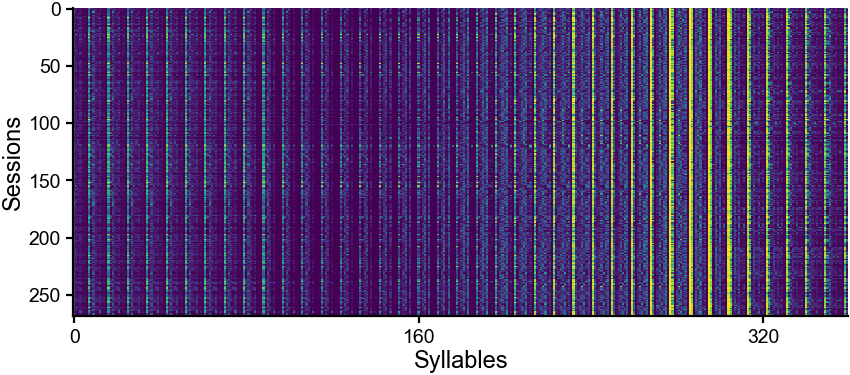

In [178]:
plt.figure(figsize=(10, 4))
plt.imshow(np.array(session_syllables), aspect='auto', cmap='viridis', interpolation='none')
plt.xticks(np.arange(0, session_syllables.shape[1], 160), np.arange(0, session_syllables.shape[1], 160))
plt.xlabel('Syllables')
plt.ylabel('Sessions')

# Dimensionality reduction

In [179]:
all_features = session_syllables.copy()

# ---- FEATURE NORMALISATION, THEN LAB VARIANCE (knobs in the header cell) -----------
# Both done HERE, on the raw session x feature matrix, so everything downstream -- PCA, the
# scaler, the LDA, every figure -- sees the corrected features. Labs come from the QC
# sheet's rig_name, so no ONE call is needed.
import importlib
import functions
importlib.reload(functions)
from functions import (lab_labels, lab_variance_explained, remove_lab_variance,
                       rank_inverse_normal)

_mouse_of_session = pd.Series(
    all_features.index.map(design_df[['mouse_name', 'session']].drop_duplicates()
                           .set_index('session')['mouse_name']),
    index=all_features.index)
lab_of_session = lab_labels(all_features.index, mouse_names=_mouse_of_session)
_n_by_lab = _mouse_of_session.groupby(lab_of_session).nunique()
print('mice per lab:', ', '.join(f'{k} {v}' for k, v in _n_by_lab.sort_values().items()))
print(f"lab share of feature variance (mean eta^2): "
      f"{lab_variance_explained(all_features, lab_of_session):.3f}"
      "   -- how much of the variance a lab label alone accounts for; it does NOT say the "
      "cause is the lab rather than the mice in it")

# FEATURE_NORM RUNS FIRST, LAB_CORRECTION SECOND. The lab correction subtracts a MEAN (and
# in 'zscore' mode divides by an SD), and both are pulled around by the skewed tails these
# proportion features have; normalising first means the lab statistics it subtracts are
# computed on well-behaved values. With FEATURE_NORM = 'per_lab' the lab correction is
# close to redundant -- ranking within lab already equalises every lab's marginal.
if FEATURE_NORM not in (None, 'none'):
    all_features = rank_inverse_normal(
        all_features,
        groups=lab_of_session if FEATURE_NORM == 'per_lab' else None)
    print(f"  after FEATURE_NORM={FEATURE_NORM!r}: "
          f"{lab_variance_explained(all_features, lab_of_session):.3f}")

# `not in (None, 'none')`, not `!= 'none'`: the header sets this to None, and None != 'none'
# is True, so the old guard fired on every run. remove_lab_variance returned the features
# untouched (it guards on None internally) so no result was ever wrong, but the cell printed
# "after None: 0.181" -- an "after" line for a correction that had not run.
if LAB_CORRECTION not in (None, 'none'):
    all_features = remove_lab_variance(all_features, lab_of_session,
                                       mode=LAB_CORRECTION, mouse_names=_mouse_of_session)
    print(f"  after LAB_CORRECTION={LAB_CORRECTION!r}: "
          f"{lab_variance_explained(all_features, lab_of_session):.3f}")


  1 session(s) had no rig in the sheet; lab taken from the mouse
  labs: 10 for 269 sessions
mice per lab: wittenlab 3, zadorlab 3, steinmetzlab 4, churchlandlab_ucla 5, hausserlab 6, churchlandlab 7, danlab 7, mainenlab 7, mrsicflogel 7, angelakilab 9
lab share of feature variance (mean eta^2): 0.181   -- how much of the variance a lab label alone accounts for; it does NOT say the cause is the lab rather than the mice in it


25 components explain 0.953 of total variance   (the 0.9 threshold is first reached at 16)


Text(0.5, 1.0, 'Explained Variance by PCA')

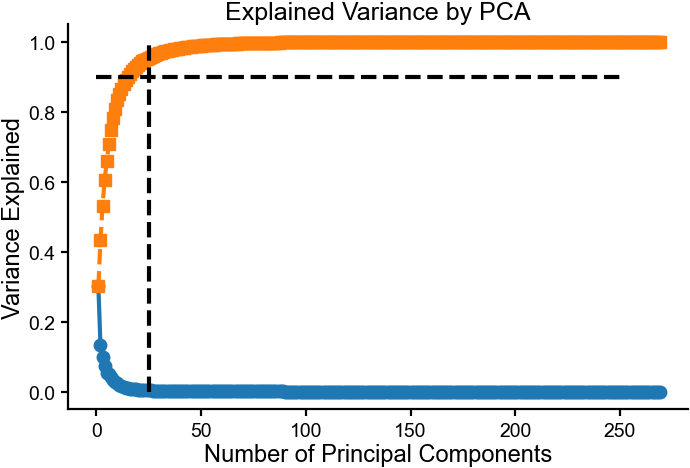

In [180]:
# PCA
n_components = np.min([np.shape(np.array(all_features))[0], np.shape(np.array(all_features))[1]])
# Step 1: Reduce dimensions with PCA
pca = PCA(n_components)
# The features are deliberately NOT standardised here, identically in functions.dim_red.
# Note this is NOT the same kind of no-op as the StandardScaler further down: PCA maximises
# RAW variance, so it is not scale-invariant, and standardising here would move the 95%
# point from 24 components to 43. If you want that, use the FEATURE_NORM knob in the header
# rather than reviving this line, so the choice is recorded in one place.
X_pca = pca.fit_transform(np.array(all_features))

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
threshold = 0.95
threshold = 0.90
_over = np.where(cumulative_variance > threshold)[0]
# +1 because np.where returns a 0-BASED INDEX and min_components is a COUNT. The old line
# was `np.where(...)[0][0]`, i.e. off by one; it never mattered because the next line
# overwrote it with a hardcoded 25.
auto_components = int(_over[0]) + 1 if len(_over) else n_components

min_components = auto_components if N_COMPONENTS == 'auto' else int(N_COMPONENTS)
# Report the variance ACTUALLY REACHED, not the threshold. The old line printed
# f"{min_components} components explain {threshold} of total variance" using the hardcoded
# 25 and the constant 0.95, so it made the same claim whatever the spectrum -- and the
# spectrum is exactly what FEATURE_NORM and LAB_CORRECTION move.
print(f'{min_components} components explain '
      f'{cumulative_variance[min_components - 1]:.3f} of total variance'
      f'   (the {threshold} threshold is first reached at {auto_components})')
if cumulative_variance[min_components - 1] < threshold:
    print(f'  WARNING: below the {threshold} threshold. Raise N_COMPONENTS to '
          f'{auto_components} to match it. Flattening the spectrum -- which is what '
          f'FEATURE_NORM does -- spreads variance over more components, so a component '
          f'count chosen for the raw features is too small here.')

# CONDITIONING GUARD. The LDA estimates a min_components x min_components within-mouse
# scatter from (n_sessions - n_mice) residual degrees of freedom. At 25 components that is
# 211 / 25 = 8.4 df per dimension, which is already thin; below ~5 the small eigenvalues of
# S_W are badly underestimated, and whitening by its inverse then AMPLIFIES exactly the
# directions that are mostly noise. This bites now that N_COMPONENTS can be 'auto':
# FEATURE_NORM='per_lab' pushes the 0.95 point to 63 components, i.e. 3.3 df per dimension.
_resid_df = len(all_features) - design_df['mouse_name'].nunique()
if _resid_df / min_components < 5:
    print(f'  WARNING: {min_components} components against {_resid_df} within-mouse '
          f'degrees of freedom = {_resid_df / min_components:.1f} df per dimension. The '
          f'within-class scatter is poorly conditioned here; prefer a smaller '
          f'N_COMPONENTS, or use the WEIGHTED notebook with SHRINKAGE > 0.')

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
plt.hlines(threshold, 0, 250, 'black', 'dashed')
plt.vlines(min_components, 0, 1, 'black', 'dashed')
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by PCA")

In [181]:
# min_components = 10

In [182]:
mat = np.array(session_syllables.copy())
mat = np.array(X_pca[:, :min_components])

scaler = StandardScaler()
norm_pop = scaler.fit_transform(mat.copy())

# LDA

In [183]:
mapping = pd.DataFrame(np.array(design_df[['mouse_name', 'session']].drop_duplicates()), columns=['mouse_name', 'session'])
df_with_sessions = session_syllables.reset_index()
mouse_names = df_with_sessions.merge(mapping, on=['session'])['mouse_name']
df = df_with_sessions.merge(mapping, on=['session'])

In [184]:
n_per_mouse = 3
lda_components = 30
lda_components = np.min([min_components, len(mouse_names.unique())-1])
# lda_components = 30
n_repeats = 10

final_matrix = np.array(norm_pop)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]
n_samples = X.shape[0]
rng = np.random.default_rng(0)

# Store repeat results
true_scores_all = []
shuffle_scores_all = []

for repeat in range(n_repeats):
    scores_true = []
    scores_shuff = []

    # Subsample balanced sessions for training in each fold
    for test_idx in range(n_samples):
        X_test = X[test_idx:test_idx+1]
        y_test = y[test_idx:test_idx+1]
        train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
        X_train_full = X[train_idx]
        y_train_full = y[train_idx]

        # --- balanced subsampling for training ---
        # the cap is a MAXIMUM contribution, not a minimum requirement -- see the
        # header cell. Every mouse stays a class, sparse ones contribute what they have.
        balanced_idx = []
        for m in np.unique(y_train_full):
            m_idx = np.where(y_train_full == m)[0]
            # cap = n_per_mouse exactly. The old `n_per_mouse - 1` dated from the
            # BROKEN guard, where cap 2 was the largest value every mouse could always
            # meet (filter_sequences keeps >= 3 sessions, leave-one-out removes at most
            # one), so nobody was ever dropped. `take = min(...)` handles short mice
            # directly, so the -1 is redundant -- and it made this cell disagree with
            # the embedding cells below, which already cap at n_per_mouse.
            take = min(n_per_mouse, len(m_idx))
            if take > 0:
                balanced_idx.extend(rng.choice(m_idx, take, replace=False))
        balanced_idx = np.array(balanced_idx)
        assert y_test[0] in y_train_full[balanced_idx], (
            "the held-out mouse is not a training class -- this fold is unanswerable")
        X_train = X_train_full[balanced_idx]
        y_train = y_train_full[balanced_idx]

        # --- true labels run ---
        lda = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train))) / len(np.unique(y_train)),
            n_components=lda_components)
        lda.fit(X_train, y_train)
        scores_true.append(lda.score(X_test, y_test))

        # --- shuffled labels run ---
        y_train_shuff = y_train.copy()
        rng.shuffle(y_train_shuff)
        lda_shuff = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train_shuff))) / len(np.unique(y_train_shuff)),
            n_components=lda_components)
        lda_shuff.fit(X_train, y_train_shuff)
        scores_shuff.append(lda_shuff.score(X_test, y_test))
        
    # store average score for this repeat
    true_scores_all.append(np.mean(scores_true))
    shuffle_scores_all.append(np.mean(scores_shuff))

print("True labels mean ± std:", np.mean(true_scores_all), np.std(true_scores_all))
print("Shuffled labels mean ± std:", np.mean(shuffle_scores_all), np.std(shuffle_scores_all))

True labels mean ± std: 0.8368029739776951 0.009173949947400065
Shuffled labels mean ± std: 0.02007434944237918 0.006481634116789105


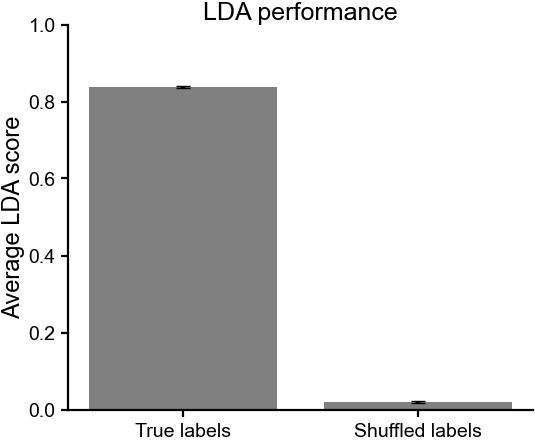

In [185]:
# Convert to arrays for convenience
true_scores = np.array(true_scores_all)
shuffle_scores = np.array(shuffle_scores_all)

# Compute means and standard deviations
means = [np.mean(true_scores), np.mean(shuffle_scores)]
stds  = [np.std(true_scores), np.std(shuffle_scores)]
std_errs = [np.std(true_scores)/np.sqrt(len(true_scores)), 
            np.std(shuffle_scores)/np.sqrt(len(shuffle_scores))]

labels = ['True labels', 'Shuffled labels']

# Create bar plot with error bars
plt.figure(figsize=(6,5))
plt.bar(labels, means, yerr=std_errs, color='grey', capsize=5) #, color=['skyblue','lightcoral']
plt.ylabel('Average LDA score')
plt.title('LDA performance')
plt.ylim(0,1)
# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'lda_score.svg', format='svg', bbox_inches='tight')
plt.show()

### How many LDA dimensions carry the mouse identity?

The sweep in `../segmentation/6_lda_score_sweep.py` varies how many **PCA** components go
*into* the LDA. This varies how many **discriminant axes** come *out* of it, with the input
fixed -- which is the question the paper actually leans on, because LD1 is read as a single
interpretable individuality axis. If identity were concentrated on LD1 the curve would
saturate immediately; if it is spread over many axes, LD1 is one slice of a broader
structure and should be described that way.

`LinearDiscriminantAnalysis(n_components=k)` cannot answer this -- `n_components` only
affects `transform`, never `predict`/`score`. So the classification is done explicitly as
nearest class mean in the first k discriminant dimensions, which with equal priors is
exactly sklearn's rule; at full rank it reproduces `lda.score` to the digit.


In [186]:
"""
LDA SCORE vs NUMBER OF LDA DIMENSIONS
"""
# reload first: this cell uses the newest additions to functions.py, so a kernel that
# imported the module earlier in the session would otherwise unpack the old 3-value return
import importlib
import functions
importlib.reload(functions)
from functions import lda_dimension_sweep

dims, dim_scores, dim_std, dim_lo, dim_hi = lda_dimension_sweep(
    design_df, session_syllables, min_components, norm_pop,
    n_per_mouse=n_per_mouse, n_repeats=n_repeats, return_ci=True, verbose=True)

n_mice = len(np.unique(pd.factorize(mouse_names)[0]))
_frac = dim_scores / dim_scores[-1]
for _f in (0.5, 0.8, 0.95):
    print(f'  {_f:.0%} of the full-rank score reached at {dims[np.argmax(_frac >= _f)]} LDA dims')
print(f'  full rank: {dim_scores[-1]:.3f}  [95% CI over mice {dim_lo[-1]:.3f}, '
      f'{dim_hi[-1]:.3f}]  (subsample spread +/-{dim_std[-1]:.3f})')


  repeat 1/10: max 0.840 at 25 LDA dims
  repeat 2/10: max 0.859 at 20 LDA dims
  repeat 3/10: max 0.855 at 23 LDA dims
  repeat 4/10: max 0.840 at 23 LDA dims
  repeat 5/10: max 0.862 at 19 LDA dims
  repeat 6/10: max 0.840 at 25 LDA dims
  repeat 7/10: max 0.848 at 19 LDA dims
  repeat 8/10: max 0.859 at 23 LDA dims
  repeat 9/10: max 0.840 at 25 LDA dims
  repeat 10/10: max 0.851 at 25 LDA dims
  50% of the full-rank score reached at 4 LDA dims
  80% of the full-rank score reached at 8 LDA dims
  95% of the full-rank score reached at 15 LDA dims
  full rank: 0.846  [95% CI over mice 0.801, 0.886]  (subsample spread +/-0.005)


wrote figures/lda_score_vs_lda_dimensions_poster_21-09-2026.png, figures/lda_score_vs_lda_dimensions_poster_21-09-2026.svg


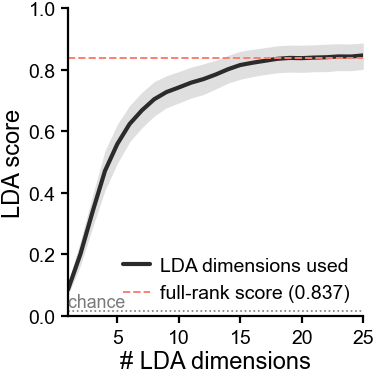

In [187]:
fig, ax = ps.figure('square', scale=.6)

ax.plot(dims, dim_scores, color=ps.STATE_INK, label='LDA dimensions used')
# Band = 95% CI from resampling MICE. NOT dim_std, which is the spread across training
# subsamples: it measures sensitivity to the random draw rather than uncertainty in the
# score, and it shrinks as n_per_mouse rises simply because a mouse with exactly
# n_per_mouse sessions has no choice left to make. See functions.bootstrap_over_mice.
ax.fill_between(dims, dim_lo, dim_hi, color=ps.STATE_INK, alpha=0.15, lw=0)

# The number from the scoring cell above. run_lda and lda_dimension_sweep now draw their
# balanced subsamples from the same stream, so the curve lands on this line EXACTLY rather
# than within draw noise -- no band needed on it any more.
_known = np.mean(true_scores)
ax.axhline(_known, color=ps.SYLLABLE['Paw 3'], ls='--', lw=1.4,
           label=f'full-rank score ({_known:.3f})')

ax.axhline(1 / n_mice, color=ps.NEUTRAL, ls=':', lw=1.2)
ax.text(dims[0], 1 / n_mice, f'chance ', ha='left', va='bottom',
        color=ps.NEUTRAL, fontsize=plt.rcParams['font.size'] * 0.8)

ax.set_xlabel('# LDA dimensions')
ax.set_ylabel(f'Mouse discriminability score\n(n_per_mouse = {n_per_mouse})')
ax.set_ylabel(f'LDA score')
ax.set_ylim(0, 1)
ax.set_xlim(dims[0], dims[-1])
# ax.set_title('25 PCA dimensions')
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
ps.savefig(fig, 'lda_score_vs_lda_dimensions', svg=True)
plt.show()

### Rerun for analyses

In [188]:
n_per_mouse = 3
lda_components = 30
lda_components = min_components

# final_matrix = np.array(norm_array)
final_matrix = np.array(norm_pop)
# final_matrix = np.array(mat)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]
n_samples = X.shape[0]
rng = np.random.default_rng(0)

# Subsample balanced sessions for training in each fold
for test_idx in range(n_samples):

    X_test = X[test_idx:test_idx+1]
    y_test = y[test_idx:test_idx+1]

    train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
    X_train_full = X[train_idx]
    y_train_full = y[train_idx]

    # THIS CELL TRAINS ON ALL SESSIONS, NOT A BALANCED SUBSAMPLE.
    # A balanced draw used to be computed here and then thrown away two lines later by
    # an unconditional `X_train = X_train_full`, so it read as live but never affected
    # anything. Removed rather than left to mislead -- and removing it also stops the
    # dead rng.choice calls from advancing the generator.
    X_train = X_train_full
    y_train = y_train_full

# Fit for visualization

In [189]:
final_matrix = np.array(norm_pop)

In [190]:
# --- fit the SAVED embedding ---
# On ALL sessions, not on whatever X_train the loop above left behind. See the header
# cell: that leftover was one arbitrary balanced draw, and because the leading LDA
# eigenvalues are near-tied, different draws rotate LD1/LD2/LD3 among themselves --
# so the saved axis was not reproducible. Fitting on everything is deterministic.
X = final_matrix.copy()
y_embed = pd.factorize(mouse_names)[0]

if EMBED_BALANCED:
    _rng = np.random.default_rng(EMBED_SEED)
    _idx = []
    for m in np.unique(y_embed):
        m_idx = np.where(y_embed == m)[0]
        _idx.extend(_rng.choice(m_idx, min(n_per_mouse - 1, len(m_idx)), replace=False))
    _idx = np.sort(np.array(_idx))
    X_fit, y_fit = X[_idx], y_embed[_idx]
    print(f"embedding fit on ONE balanced draw: {len(_idx)} sessions "
          f"(seed {EMBED_SEED}) -- reproducible, but draw-dependent")
else:
    X_fit, y_fit = X, y_embed
    print(f"embedding fit on ALL {len(X)} sessions, "
          f"{len(np.unique(y_embed))} mice -- deterministic")

_ncls = len(np.unique(y_fit))
lda = LinearDiscriminantAnalysis(priors=np.ones(_ncls) / _ncls,
                                 n_components=min(lda_components, _ncls - 1))
lda.fit(X_fit, y_fit)
final_transformed = lda.transform(X)
print("LDA explained_variance_ratio_ (top 6):",
      np.round(lda.explained_variance_ratio_[:6], 3),
      "\n  near-equal leading values mean those axes are free to rotate among "
      "themselves; treat them as a subspace, not as individual axes")
clustered = pd.DataFrame(final_transformed)
clustered['mouse_name'] = mouse_names
clustered['mouse_number'] = pd.factorize(clustered['mouse_name'])[0]
# lab travels with the embedding whether or not LAB_CORRECTION was applied, so any
# downstream figure can colour or group by it (and so a 'none' run can be compared with
# a corrected one on the same axis)
if 'lab_of_session' in globals():
    clustered['lab'] = list(lab_of_session)
    clustered['lab_number'] = pd.factorize(clustered['lab'])[0]
# clustered['litter_id'] = litter_id
# clustered['litter_number'] = pd.factorize(clustered['litter_id'])[0]
clustered['session'] = session_syllables.reset_index()['session']

# clustered = clustered.merge(cluster_df[['mouse_name', 'mouse_cluster']].drop_duplicates(), on=['mouse_name'])

embedding fit on ALL 269 sessions, 58 mice -- deterministic
LDA explained_variance_ratio_ (top 6): [0.164 0.129 0.092 0.09  0.074 0.068] 
  near-equal leading values mean those axes are free to rotate among themselves; treat them as a subspace, not as individual axes


In [191]:
len(clustered.mouse_name.unique())

58

### Structural coefficients

In [207]:
component_to_plot = 3

channels ('paw', 'whisk', 'lick'): 40 timesteps x 9 features


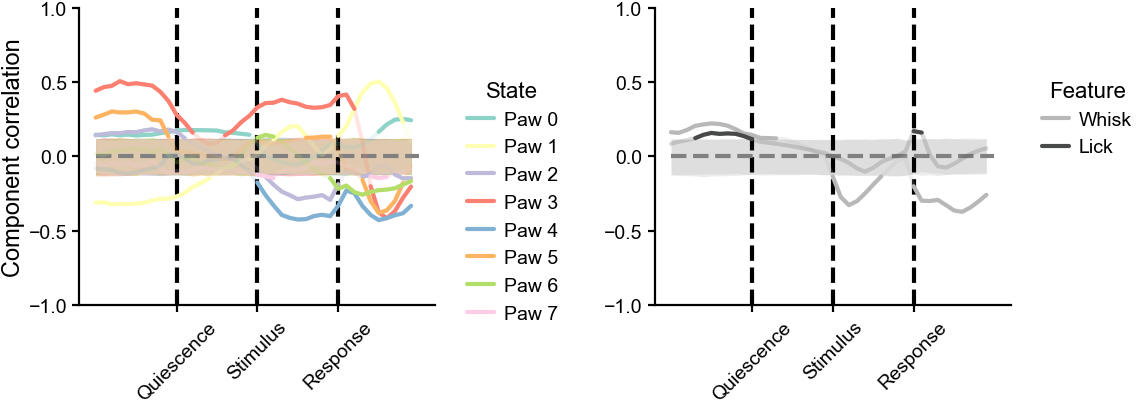

In [208]:
# 1. Get the LDA scores for all trials (their position on the LD1 axis)
lda_scores = final_transformed
y_true = lda_scores[:, component_to_plot]

all_feats = np.array(session_syllables)

# THE LAYOUT IS DERIVED, NOT ASSUMED. This cell used to hardcode 40 timesteps x 9 features
# per timestep; with SYLLABLE_CHANNELS set to anything but the full set the matrix is
# narrower (paw only -> 7 per timestep, 280 columns) and the reshape below fails. Read the
# channel list instead and check the arithmetic closes.
_chan = tuple(globals().get('SYLLABLE_CHANNELS', ('paw', 'whisk', 'lick')))
HAS_PAW, HAS_WHISK, HAS_LICK = ('paw' in _chan), ('whisk' in _chan), ('lick' in _chan)
n_paw_cols = (n_paw_states - 1) if HAS_PAW else 0
n_features_per_step = n_paw_cols + int(HAS_WHISK) + int(HAS_LICK)

# TRIAL_TYPE_SPLIT (header cell) lays one block of timesteps per trial type side by side, so
# the matrix is n_levels x timesteps x channels wide. EACH LEVEL GETS ITS OWN FIGURE and its
# own permutation null. Correlating the concatenation as one long series would instead draw
# a trace out of the correct-trial ITI straight into the incorrect-trial pre-quiescence.
_groups = globals().get('TRIAL_TYPE_GROUPS', None) or [None]
block_w = all_feats.shape[1] // len(_groups)
timesteps = block_w // n_features_per_step
assert timesteps * n_features_per_step * len(_groups) == all_feats.shape[1], (
    f'{all_feats.shape[1]} features do not divide into {len(_groups)} trial-type block(s) of '
    f'{n_features_per_step} features per timestep for channels {_chan}')
print(f'channels {_chan}: {timesteps} timesteps x {n_features_per_step} features'
      + (f', separately for {len(_groups)} trial types {_groups}' if _groups != [None] else ''))


def colwise_pearsonr(X, y):
    """Vectorized per-column Pearson r between each column of X and y."""
    Xc = X - X.mean(axis=0, keepdims=True)
    yc = y - y.mean()
    num = Xc.T @ yc
    denom = np.sqrt((Xc**2).sum(axis=0)) * np.sqrt((yc**2).sum())
    return num / denom


# HOW THE NULL BAND AND THE TRACE ARE LAYERED
# The shuffled band is the 95% null interval for r at that timestep, so a trace
# INSIDE it is indistinguishable from chance and a trace outside it is the actual
# result. The plot now says that visually instead of leaving it to be eyeballed:
#   'dim_trace'   (default) -- band stays underneath at low alpha, and the trace is
#                   drawn twice: faint everywhere, full-strength only where it
#                   leaves the band. Significant excursions are the only solid ink.
#                   Preferred with 8 overlapping paw states, where stacking opaque
#                   bands turns the panel to mush.
#   'band_on_top' -- the literal "band over the trace": bands are drawn last at high
#                   alpha so they physically cover the non-significant stretches.
#                   Cleaner on the 2-line whisk/lick panel than on the paw panel.
BAND_MODE = 'dim_trace'   # 'dim_trace' or 'band_on_top'
ALPHA_IN_BAND = 0.2       # trace alpha inside the null band ('dim_trace')
BAND_ALPHA_TOP = 0.85     # band opacity when it is drawn over the trace
n_perms = 1000


def _outside(y, lo, hi):
    """y with the inside-the-null-band samples set to NaN, so only the significant
    stretches get drawn. The faint full-length copy underneath fills the gaps that
    NaN leaves at each crossing."""
    return np.where((y >= lo) & (y <= hi), np.nan, y)


def _trace(ax, y, lo, hi, color, label, lw=3):
    if BAND_MODE == 'dim_trace':
        ax.plot(time_axis, y, color=color, lw=lw, alpha=ALPHA_IN_BAND, zorder=2)
        ax.plot(time_axis, _outside(y, lo, hi), color=color, lw=lw, alpha=1.0,
                label=label, zorder=3)
    else:
        ax.plot(time_axis, y, color=color, lw=lw, alpha=1.0, label=label, zorder=2)


def _band(ax, lo, hi, color, alpha_under):
    if BAND_MODE == 'dim_trace':
        ax.fill_between(time_axis, lo, hi, color=color, alpha=alpha_under,
                        linewidth=0, zorder=1)
    else:
        ax.fill_between(time_axis, lo, hi, color=color, alpha=BAND_ALPHA_TOP,
                        linewidth=0, zorder=4)


time_axis = np.arange(timesteps)
palette = sns.color_palette('Set3', n_paw_states)
struct_by_group = {}      # {trial type: (timesteps x n_features_per_step) of r}

for _gi, _gname in enumerate(_groups):
    feats = all_feats[:, _gi * block_w:(_gi + 1) * block_w]

    # 2. Correlate each original syllable feature with the true LDA scores
    struct_coeffs = colwise_pearsonr(feats, y_true)
    reshaped_struct = struct_coeffs.reshape(timesteps, n_features_per_step)
    struct_by_group[_gname] = reshaped_struct

    paw_importance = reshaped_struct[:, :n_paw_cols] if HAS_PAW else None
    whisk_importance = reshaped_struct[:, n_paw_cols] if HAS_WHISK else None
    lick_importance = reshaped_struct[:, n_paw_cols + int(HAS_WHISK)] if HAS_LICK else None

    # Paw State 1 (index 1) was dropped from the design matrix as the redundant one-hot
    # reference column (binarize() deletes it at every timestep since the 8 paw states
    # sum to 1). Reconstruct its per-session, per-timestep value as 1 - the other 7
    # paw probabilities, then correlate that reconstructed series with the LDA scores.
    if HAS_PAW:
        feats_reshaped = feats.reshape(-1, timesteps, n_features_per_step)
        omitted_paw_state = 1 - feats_reshaped[:, :, :n_paw_cols].sum(axis=2)  # (n_sessions, timesteps)
        omitted_struct_coeffs = colwise_pearsonr(omitted_paw_state, y_true)

        # Assemble all 8 paw states in their true order (0..7)
        paw_importance_full = np.zeros((timesteps, n_paw_states))
        paw_importance_full[:, 0] = paw_importance[:, 0]
        paw_importance_full[:, 1] = omitted_struct_coeffs
        paw_importance_full[:, 2:] = paw_importance[:, 1:]

    # 3. Control: shuffle the LDA assignments (permute which score belongs to which
    # session) and recompute the same correlation profiles many times, to get a null
    # distribution / 95% CI band at each timestep for every feature. The null is redrawn
    # per trial type -- the block for a rare trial type is a noisier estimate, so its null
    # is wider, and one band for all of them would understate that.
    rng = np.random.default_rng(0)

    shuffled_struct = np.zeros((n_perms, timesteps, n_features_per_step))
    shuffled_omitted = np.zeros((n_perms, timesteps))
    for p in range(n_perms):
        y_shuff = rng.permutation(y_true)
        shuffled_struct[p] = colwise_pearsonr(feats, y_shuff).reshape(timesteps, n_features_per_step)
        if HAS_PAW:
            shuffled_omitted[p] = colwise_pearsonr(omitted_paw_state, y_shuff)

    if HAS_PAW:
        shuffled_paw = shuffled_struct[:, :, :n_paw_cols]
        shuffled_paw_full = np.zeros((n_perms, timesteps, n_paw_states))
        shuffled_paw_full[:, :, 0] = shuffled_paw[:, :, 0]
        shuffled_paw_full[:, :, 1] = shuffled_omitted
        shuffled_paw_full[:, :, 2:] = shuffled_paw[:, :, 1:]
        paw_ci_lo, paw_ci_hi = np.percentile(shuffled_paw_full, [2.5, 97.5], axis=0)
    if HAS_WHISK:
        whisk_ci_lo, whisk_ci_hi = np.percentile(shuffled_struct[:, :, n_paw_cols], [2.5, 97.5], axis=0)
    if HAS_LICK:
        lick_ci_lo, lick_ci_hi = np.percentile(shuffled_struct[:, :, n_paw_cols + int(HAS_WHISK)],
                                               [2.5, 97.5], axis=0)

    # 4. Plot - paw states and whisk/lick as separate panels
    _panels = (['paw'] if HAS_PAW else []) + (['wl'] if (HAS_WHISK or HAS_LICK) else [])
    fig, _axs = plt.subplots(1, len(_panels), figsize=(6 * len(_panels), 4.5),
                             sharey=False, squeeze=False)
    _axs = _axs[0]
    ax_paw = _axs[_panels.index('paw')] if HAS_PAW else None
    ax_wl = _axs[_panels.index('wl')] if (HAS_WHISK or HAS_LICK) else None

    for ax in [a for a in (ax_paw, ax_wl) if a is not None]:
        ax.vlines(10, -1, 1, color='k', linestyle='--')
        ax.vlines(20, -1, 1, color='k', linestyle='--')
        ax.vlines(30, -1, 1, color='k', linestyle='--')
        ax.hlines(0, 0, timesteps, color='grey', linestyle='--')
        ax.set_xticks([10, 20, 30])
        ax.set_xticklabels(['Quiescence', 'Stimulus', 'Response'], rotation=45)

    if HAS_PAW:
        for state in range(n_paw_states):
            _band(ax_paw, paw_ci_lo[:, state], paw_ci_hi[:, state], palette[state], 0.5)
        for state in range(n_paw_states):
            _trace(ax_paw, paw_importance_full[:, state],
                   paw_ci_lo[:, state], paw_ci_hi[:, state],
                   palette[state], f'Paw {state}')
        ax_paw.set_ylim([-1, 1])
        ax_paw.set_ylabel('Component correlation')
        ax_paw.legend(title='State', bbox_to_anchor=(1.05, .8), loc='upper left')

    if ax_wl is not None:
        if HAS_WHISK:
            _band(ax_wl, whisk_ci_lo, whisk_ci_hi, "#b8b8b8", 0.2)
            _trace(ax_wl, whisk_importance, whisk_ci_lo, whisk_ci_hi, "#b8b8b8", 'Whisk')
        if HAS_LICK:
            _band(ax_wl, lick_ci_lo, lick_ci_hi, "#484949", 0.1)
            _trace(ax_wl, lick_importance, lick_ci_lo, lick_ci_hi, "#484949", 'Lick')
        ax_wl.set_ylim([-1, 1])
        if not HAS_PAW:
            ax_wl.set_ylabel('Component correlation')
        ax_wl.legend(title='Feature', bbox_to_anchor=(1.05, .8), loc='upper left')

    if _gname is not None:
        fig.suptitle(f'LD{component_to_plot + 1}  --  {_gname} trials')
    plt.tight_layout()
    # plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'feature_importances_lda.svg', format='svg', bbox_inches='tight')
    plt.show()


# Save data

In [194]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/data_files/'
current_date = datetime.now().strftime('%d-%m-%Y')

# ---- THE NAME IS DERIVED FROM THE KNOBS, NEVER TYPED ------------------------------
# The word 'lab' used to be hardcoded into this f-string. The result, on 19-09-2026:
#   mouse_LDA_5_bins_25_19-09-2026       sha256 59295fed...   21:38
#   mouse_LDA_5_bins_lab_25_19-09-2026   sha256 59295fed...   21:41
# Identical bytes, saved three minutes apart, BOTH lab-zscored -- and only one of them
# saying so. Anything reading the first name would have used a lab-corrected embedding
# believing it was the raw one. Deriving the tag from the knobs makes that impossible.
#
# `globals().get` rather than a bare name: LDA_analyses_pipeline_WEIGHTED has no
# LAB_CORRECTION knob, and this block is kept identical in both notebooks.
_lab = globals().get('LAB_CORRECTION')
_norm = globals().get('FEATURE_NORM')
_tag = ''
if _lab not in (None, 'none'):
    _tag += f'_lab{_lab}'            # _labcenter | _labzscore
if _norm not in (None, 'none'):
    _tag += f'_norm{_norm}'          # _normglobal | _normper_lab
if not _tag:
    # say "uncorrected" OUT LOUD. An absent tag is ambiguous with an older file written
    # before this block existed; '_raw' is not.
    _tag = '_raw'

filename = f"mouse_LDA_5_bins{_tag}_{min_components}_{current_date}"
print('saving:', filename)
clustered['binned1'] = pd.cut(clustered[0], 5)
clustered['binned2'] = pd.cut(clustered[1], 5)
clustered['binned3'] = pd.cut(clustered[2], 5)
clustered['binned4'] = pd.cut(clustered[3], 5)
clustered['binned5'] = pd.cut(clustered[4], 5)
import pickle
# pickle.dump(open(results_df, 'wb'), filename)
# clustered.to_pickle(data_path+filename)  

saving: mouse_LDA_5_bins_raw_25_21-09-2026


In [209]:
# --- Save proficiency correlation profiles for ALL LDA components -----------
# Per-timestep correlation of eaperhaps you can consider the paw movement speed as a metricch behavioural feature with each LDA score,
# reshaped to (timesteps, channels) -- same computation as the structural-
# coefficients plot above, looped over every LDA component. Consumed by
# whisk_state_timepoints:  r_prof = pd.read_parquet(file)[variable]  ("whisk"/"lick").
# Component index is 0-based, so LDA 1 -> component0 file.
#
# THE LAYOUT IS DERIVED FROM SYLLABLE_CHANNELS, not assumed. This cell used to hardcode
# reshape(40, n_paw_states - 1 + 2); with a channel subset the matrix is narrower (paw only
# -> 280 = 40 x 7) and the reshape raises. The column NAMES follow the same subset, so a
# consumer that asks for "whisk" gets a clear KeyError rather than a silently shifted column.
from scipy.stats import pearsonr
_feats = np.array(session_syllables)
_chan37 = tuple(globals().get('SYLLABLE_CHANNELS', ('paw', 'whisk', 'lick')))
_cols = ([f"paw_{s}" for s in range(n_paw_states - 1)] if 'paw' in _chan37 else []) \
        + (["whisk"] if 'whisk' in _chan37 else []) + (["lick"] if 'lick' in _chan37 else [])
_per_step = len(_cols)
# TRIAL_TYPE_SPLIT (header cell) stacks one block of timesteps per trial type, so the width
# is n_levels x timesteps x channels. The profile is then written LONG -- one timesteps-row
# group per level, tagged by a `trial_type` column -- rather than reshaped as if the levels
# were extra timesteps. With no split the frame is exactly what it was before, with no extra
# column, so whisk_state_timepoints (`pd.read_parquet(file)[variable]`) keeps working.
_groups38 = globals().get('TRIAL_TYPE_GROUPS', None)
_n_blocks = len(_groups38) if _groups38 else 1
_block_w = _feats.shape[1] // _n_blocks
_timesteps = _block_w // _per_step
assert _timesteps * _per_step * _n_blocks == _feats.shape[1], (
    f'{_feats.shape[1]} features do not divide into {_n_blocks} trial-type block(s) of '
    f'{_per_step} per timestep for {_chan37}')
for _comp in range(final_transformed.shape[1]):
    _sc = np.array([pearsonr(_feats[:, i], final_transformed[:, _comp])[0]
                    for i in range(_feats.shape[1])])
    if _groups38:
        _prof = pd.concat(
            [pd.DataFrame(_sc[_b * _block_w:(_b + 1) * _block_w].reshape(_timesteps, _per_step),
                          columns=_cols).assign(trial_type=_g)
             for _b, _g in enumerate(_groups38)], ignore_index=True)
    else:
        _prof = pd.DataFrame(_sc.reshape(_timesteps, _per_step), columns=_cols)
    # _prof.to_parquet(data_path + f"lda_corr_profile_component{_comp}_{current_date}")
print(f"Saved {final_transformed.shape[1]} LDA correlation profiles "
      f"({_timesteps} timesteps x {_per_step} channels: {', '.join(_cols)}"
      + (f" x {_n_blocks} trial types {_groups38}" if _groups38 else "") + ") -> "
      f"{data_path}lda_corr_profile_component*_{current_date}")


Saved 25 LDA correlation profiles (40 timesteps x 9 channels: paw_0, paw_1, paw_2, paw_3, paw_4, paw_5, paw_6, whisk, lick) -> /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/clustering/data_files/lda_corr_profile_component*_21-09-2026


In [210]:
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# filename = "mouse_LDA_quadrants"
# clustered.loc[(clustered[0]<0) & (clustered[1]<0), 'quadrant'] = 3
# clustered.loc[(clustered[0]>0) & (clustered[1]>0), 'quadrant'] = 1
# clustered.loc[(clustered[0]>0) & (clustered[1]<0), 'quadrant'] = 2
# clustered.loc[(clustered[0]<0) & (clustered[1]>0), 'quadrant'] = 4
# import pickle
# # pickle.dump(open(results_df, 'wb'), filename)
# clustered.to_pickle(data_path+filename) 

In [211]:
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# filename = "mouse_LDA_quadrants"

# clustered['binned1'] = pd.cut(clustered[0], 3)
# clustered['binned2'] = pd.cut(clustered[1], 3)
# clustered['binned3'] = pd.cut(clustered[2], 3)
# # clustered['binned4'] = pd.cut(clustered[3], 5)
# # clustered['binned5'] = pd.cut(clustered[4], 5)
# import pickle
# # pickle.dump(open(results_df, 'wb'), filename)
# # clustered.to_pickle(data_path+filename)  

wrote figures/lda12_mice_poster_21-09-2026.png, figures/lda12_mice_poster_21-09-2026.svg


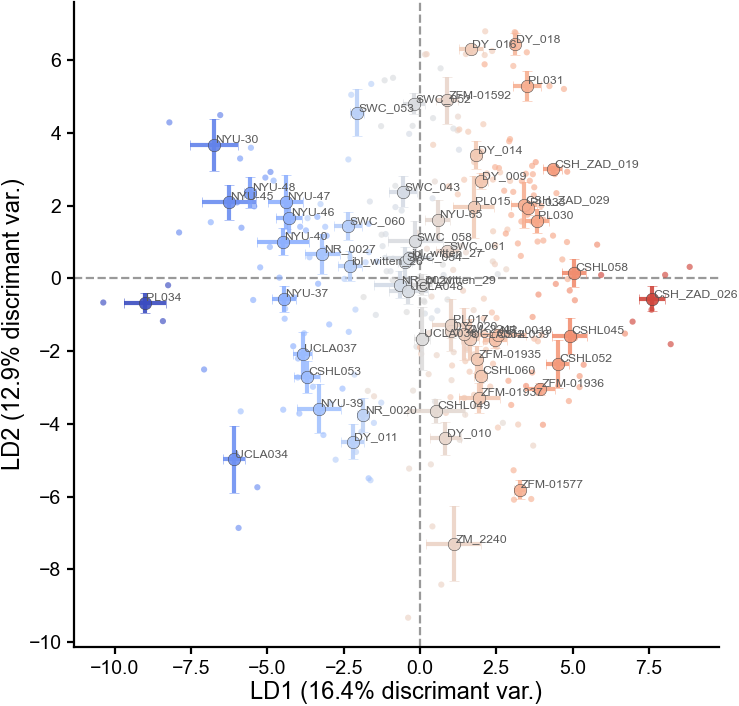

In [212]:
"""
MICE IN THE LDA SPACE -- one point per mouse, coloured by its LD1 position.
Colour, panel size, type and export all come from paper_style, so this figure
matches every other LD1 figure in the paper. ps.use('paper') in the header cell
re-renders it at journal size with no other edit.

Individual SESSIONS are drawn underneath as small dots in their mouse's colour
(SHOW_SESSIONS), so the spread the error bars summarise is visible directly.
Axis labels carry each axis's share of the between-mouse variance, taken from
`lda.explained_variance_ratio_` of the embedding fit two cells up -- note that
this is the share of the DISCRIMINANT variance, not of the variance in the
original syllable features, and that near-tied leading values mean LD1/LD2 are
free to rotate within their subspace.
"""
SHOW_LABELS = True        # mouse names next to the points; crowded at 58 mice
SEM_PER_MOUSE = True     # False keeps the original fixed /sqrt(4);
                          # True uses each mouse's own session count (see below)
SHOW_SESSIONS = True      # single sessions as small dots under the mouse means

df_lda = clustered.copy()
grouped = df_lda.groupby(['mouse_name', 'mouse_number'])
mouse_means = grouped[[0, 1, 2]].mean()
if SEM_PER_MOUSE:
    # NOTE this changes the error bars: the original divides every mouse's SD by
    # sqrt(4) regardless of how many sessions it actually has (3 to 16 here).
    mouse_stds = grouped[[0, 1, 2]].std().div(np.sqrt(grouped.size()), axis=0)
else:
    mouse_stds = grouped[[0, 1, 2]].std() / np.sqrt(4)

ld1 = mouse_means[0].values
colors = ps.ld1_colors(ld1)          # coolwarm, symmetric about 0

# variance explained per discriminant, for the axis labels. getattr guard so the
# cell still runs if it is executed without the embedding cell in the namespace.
_evr = getattr(lda, 'explained_variance_ratio_', None)
def _ld_label(k):
    if _evr is None or k >= len(_evr):
        return f'LD{k + 1}'
    return f'LD{k + 1} ({100 * _evr[k]:.1f}% discrimant var.)'

fig, ax = ps.figure('single', scale=1.5)

if SHOW_SESSIONS:
    # every session in its mouse's colour -- same colour object as the mean point,
    # so the two cannot drift apart if ld1_norm changes.
    _cmap = {m[0]: c for m, c in zip(mouse_means.index, colors)}
    _sess_c = np.array([_cmap[m] for m in df_lda['mouse_name']])
    ax.scatter(df_lda[0], df_lda[1], s=20, c=_sess_c,
               alpha=0.65, linewidths=0, zorder=1)

for (mouse, cvec) in zip(mouse_means.index, colors):
    mean_vals = mouse_means.loc[mouse]
    std_vals = mouse_stds.loc[mouse]
    ax.errorbar(mean_vals[0], mean_vals[1],
                xerr=std_vals[0], yerr=std_vals[1],
                fmt='o', color=cvec, ecolor=cvec, alpha=0.9,
                markeredgecolor='0.25', markeredgewidth=0.4, zorder=2)
    if SHOW_LABELS:
        ax.text(mean_vals[0] + 0.05, mean_vals[1] + 0.05, str(mouse[0]),
                fontsize=plt.rcParams['font.size'] * 0.55, color='0.35', zorder=3)

ax.axvline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
ax.axhline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
# SQUARE PLOTTING AREA, not a square figure: set_box_aspect fixes the ratio of the
# AXES rectangle itself, so the colorbar and labels take their space outside it and
# the data area stays square whatever the figure size or mode.
ax.set_box_aspect(1)
# If instead you want one LD unit to be the same length on both axes -- which is the
# honest choice when distances in LDA space are being read -- use equal DATA aspect
# and symmetric limits; the box then comes out square as a consequence:
#     lim = np.nanmax(np.abs(np.r_[ax.get_xlim(), ax.get_ylim()]))
#     ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')

# ps.ld1_colorbar(ax, label='LD1', values=ld1, fraction=0.046, pad=0.02)
ax.set_xlabel(_ld_label(0))
ax.set_ylabel(_ld_label(1))
fig.tight_layout()
ps.savefig(fig, 'lda12_mice', svg=True)   # PNG + vector master
plt.show()


### The same mice in 3D (LD1 x LD2 x LD3)

The leading discriminants are near-tied in `explained_variance_ratio_`, so they rotate freely among themselves and the LD1/LD2 view above is one slice through a subspace rather than *the* picture. These are static panels of the same cloud seen from a few angles: a separation that only appears at one viewpoint is a property of the projection, not of the mice.

wrote figures/lda123_mice_3d_poster_21-09-2026.png, figures/lda123_mice_3d_poster_21-09-2026.svg


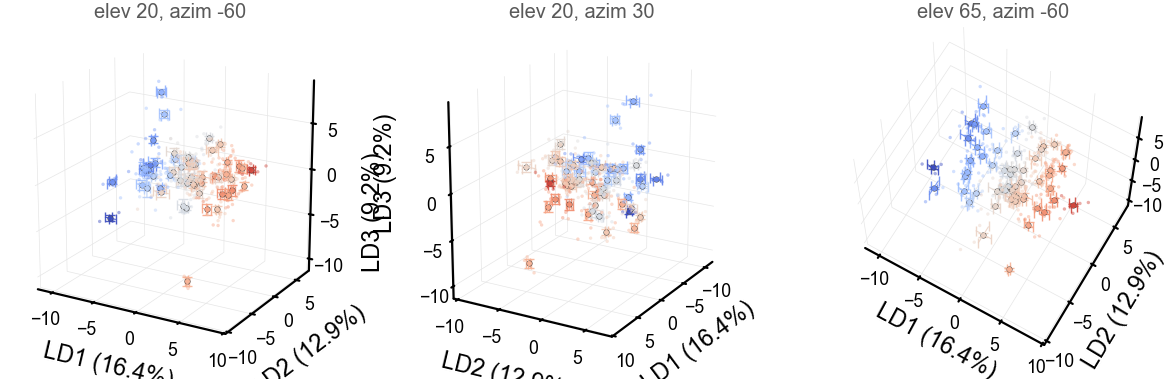

In [199]:
"""
MICE IN THE LDA SPACE, IN 3D -- LD1 x LD2 x LD3. STATIC matplotlib panels.

Same content as the LD1/LD2 figure above (one point per mouse, sessions
underneath, coloured by LD1), with the third discriminant as the depth axis.
Plain matplotlib, inline backend, no widget -- it renders as an image and
exports through ps.savefig like every other figure in the paper.

WHY SEVERAL VIEWPOINTS. The embedding cell prints `explained_variance_ratio_`
and its leading values are near-tied, which means LD1/LD2/LD3 are free to
ROTATE AMONG THEMSELVES -- no single one of them is a privileged direction, and
any ONE projection can make mice look separated (or overlapping) by accident of
the angle. Rotating is the natural way to check that; with a static figure the
substitute is to draw the same cloud from a few angles and only believe the
separations that hold up in all of them. VIEWS sets the angles.

To turn it by hand instead, set VIEWS to a single (elev, azim) pair and edit
the numbers -- elev is degrees above the LD1/LD2 plane, azim is rotation about
the vertical (LD3) axis.
"""

# (elev, azim) per panel. One entry -> a single large panel.
VIEWS_3D = [(20, -60), (20, 30), (65, -60)]
SHOW_SESSIONS_3D = True    # single sessions as small dots under the mouse means
SHOW_LABELS_3D = False     # mouse names as text; unreadable at 58 mice in 3D
SHOW_ERRORBARS_3D = True   # SEM bars per mouse (same definition as the 2D cell)
PANEL_IN_3D = 4.2          # inches per panel

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

df_lda3 = clustered.copy()
_g3 = df_lda3.groupby(['mouse_name', 'mouse_number'])
mouse_means3 = _g3[[0, 1, 2]].mean()
# per-mouse SEM using each mouse's own session count (SEM_PER_MOUSE=True in the 2D cell).
# fillna(0) because a mouse with a single session has no SD -- it gets no bar rather
# than vanishing from the figure.
mouse_sems3 = _g3[[0, 1, 2]].std().div(np.sqrt(_g3.size()), axis=0).fillna(0.0)

ld1_3 = mouse_means3[0].values
colors3 = ps.ld1_colors(ld1_3)                      # coolwarm, symmetric about 0
_cmap3 = {m[0]: c for m, c in zip(mouse_means3.index, colors3)}

# axis labels carry each discriminant's share of the BETWEEN-MOUSE (discriminant)
# variance -- not of the variance in the original syllable features
_evr3 = getattr(lda, 'explained_variance_ratio_', None)
def _ld_label3(k):
    if _evr3 is None or k >= len(_evr3):
        return f'LD{k + 1}'
    return f'LD{k + 1} ({100 * _evr3[k]:.1f}%)'

_nv = len(VIEWS_3D)
fig3, axs3 = plt.subplots(1, _nv, figsize=(PANEL_IN_3D * _nv, PANEL_IN_3D * 1.05),
                          subplot_kw={'projection': '3d'}, squeeze=False)
axs3 = axs3.ravel()

for ax3, (elev, azim) in zip(axs3, VIEWS_3D):
    if SHOW_SESSIONS_3D:
        # every session in its mouse's colour -- same colour object as the mean point.
        # depthshade=False so a point's colour means its LD1 value and nothing else;
        # the default fades far points and would read as a second colour scale.
        _sc3 = np.array([_cmap3[m] for m in df_lda3['mouse_name']])
        ax3.scatter(df_lda3[0], df_lda3[1], df_lda3[2], s=6, c=_sc3,
                    alpha=0.45, linewidths=0, depthshade=False)

    for (mouse, mean_vals), (_, sem_vals), cvec in zip(
            mouse_means3.iterrows(), mouse_sems3.iterrows(), colors3):
        if SHOW_ERRORBARS_3D:
            ax3.errorbar(mean_vals[0], mean_vals[1], mean_vals[2],
                         xerr=sem_vals[0], yerr=sem_vals[1], zerr=sem_vals[2],
                         fmt='o', ms=4, color=cvec, ecolor=cvec, alpha=0.9,
                         elinewidth=0.8, markeredgecolor='0.25', markeredgewidth=0.4)
        else:
            ax3.scatter(mean_vals[0], mean_vals[1], mean_vals[2], s=28, color=cvec,
                        edgecolors='0.25', linewidths=0.4, depthshade=False)
        if SHOW_LABELS_3D:
            ax3.text(mean_vals[0], mean_vals[1], mean_vals[2], str(mouse[0]),
                     fontsize=plt.rcParams['font.size'] * 0.5, color='0.35')

    ax3.view_init(elev=elev, azim=azim)
    # labelpad is generous on purpose: 3d tick labels sit INSIDE the axis line, so a
    # small pad puts the axis name straight through them
    ax3.set_xlabel(_ld_label3(0), labelpad=6)
    ax3.set_ylabel(_ld_label3(1), labelpad=6)
    ax3.zaxis.set_rotate_label(False)   # keep it upright, not tilted with the pane
    ax3.set_zlabel(_ld_label3(2), labelpad=14, rotation=90)
    ax3.tick_params(pad=1, labelsize=plt.rcParams['font.size'] * 0.8)
    # EQUAL DATA ASPECT: one LD unit is the same length on all three axes, so the
    # cloud is not stretched differently per axis and the panels can be compared.
    _rng3 = [np.ptp(df_lda3[k]) for k in (0, 1, 2)]
    ax3.set_box_aspect(_rng3)
    if _nv > 1:
        ax3.set_title(f'elev {elev}, azim {azim}',
                      fontsize=plt.rcParams['font.size'] * 0.9, color='0.35')
    # the 3d panes carry no information; the ticks already give the scale
    for _pane in (ax3.xaxis, ax3.yaxis, ax3.zaxis):
        _pane.pane.set_alpha(0.0)
        _pane._axinfo['grid'].update(color='0.9', linewidth=0.5)

# subplots_adjust, NOT tight_layout: tight_layout measures 2d artists and consistently
# clips the z label of a 3d axes, which is what the right-hand panel loses first
fig3.subplots_adjust(left=0.02, right=0.94, bottom=0.04, top=0.94, wspace=0.22)
ps.savefig(fig3, 'lda123_mice_3d', svg=True)   # PNG + vector master
plt.show()


### Example sessions at the extremes of the LD1/LD2/LD3 subspace

What does a mouse at one end of an individuality axis actually *do* differently? These
panels are fig 2A (syllable composition across the four trial epochs) drawn for the
sessions furthest along each of the six axis ends -- both poles of LD1, LD2 and LD3 -- so
the embedding can be read against the behaviour it came from. LD3 is included because the
leading discriminants are near-tied and rotate among themselves: the ends of LD3 are part
of the same subspace, not a separate, lesser axis.

In [200]:
"""
SYLLABLE PANELS FOR THE SESSIONS AT THE EXTREMES OF THE LD1/LD2/LD3 SUBSPACE
===========================================================================
The panel is fig 2A and is drawn by paper-individuality/syllable_panels.py, the same
module 2_pre-trial/fig2.ipynb now calls -- same palette, same syllable ordering, same
sort mode, so these panels and fig 2A can be put side by side.

WHICH SESSIONS. For each direction the session furthest along it is taken. Three knobs:

  EXTREME_BY 'session' -- the single most extreme SESSION. What "extreme point in the
                 2D plot" literally means, but a lone session can be extreme because of
                 a bad camera day rather than because of the mouse, and one session is
                 not evidence about an animal.
             'mouse'  -- the most extreme MOUSE (by the mean of its sessions), then that
                 mouse's most TYPICAL session (closest to its own mean). Slower to reach
                 the edge of the cloud, but what it shows is reproducible within the
                 animal. Prefer this one for anything that goes in the paper.

  MAX_MISSING  skip sessions whose sequences are more than this fraction NaN. NOT
               cosmetic: the mouse at the LD1-low pole (CSH_ZAD_026) is missing 10-21%
               of its bins -- almost all of it a hole in the middle of the ITI, where
               40% of its bins are gone -- and the worst-tracked mouse in the file
               (NYU-30, 32-54% missing, flagged 'need to revise' in the QC sheet, which
               QC_STRICTNESS='filtered_out' does NOT drop) sits near the other end of
               LD1. A panel that is a fifth empty cannot be read as behaviour. None
               shows the literal extremes regardless.

               THE SCREEN CHANGES WHAT IS DRAWN, NEVER THE EMBEDDING. A mouse is still
               ranked on all of its sessions; only the session shown for it has to pass.
               If none of its sessions pass, the next mouse along that direction is used
               and the skip is printed, so the figure never quietly claims that a
               well-tracked mouse is the extreme one. (Dropping the badly-tracked mice
               from the LDA itself is a separate question: recomputing the embedding
               from complete trials only leaves LD1 essentially unchanged, |r| = 0.99,
               so the missing data is a problem for READING these panels, not evidence
               that the axis is an artifact.)

  DIRECTIONS   the SIX axis ends -- both poles of LD1, LD2 and LD3. The vectors are 3d
               and normalised, so a corner like 'LD1+LD3': (1, 0, 1) works as well.

               WHY LD3 IS IN HERE. The embedding's leading eigenvalues are near-tied
               (the 3d figure above says so), which means LD1/LD2/LD3 are free to rotate
               among themselves: no one of them is a privileged direction, and the
               behaviour at the ends of LD3 belongs to the individuality subspace exactly
               as LD1's does. Showing only LD1/LD2 shows two thirds of the picture. This
               is NOT a claim that LD3 means something on its own -- read the six panels
               as six points on the edge of one cloud, not as three separate axes.
"""
import importlib
import re
import syllable_panels as sp
importlib.reload(sp)          # kernels cache modules; see the paper_style note in cell 0

EXTREME_BY = 'session'        # 'mouse' (recommended) or 'session'
MAX_MISSING = 0.02            # None = no screen; 0.05 = at most 5% of bins missing
SORT_MODE_EX = 'within_bin'   # as in fig 2A: 'within_bin' or 'none' (true raster)
DIRECTIONS = {'LD1 low': (-1, 0, 0), 'LD1 high': (1, 0, 0),
              'LD2 low': (0, -1, 0), 'LD2 high': (0, 1, 0),
              'LD3 low': (0, 0, -1), 'LD3 high': (0, 0, 1)}
MAP_PLANES = [(0, 1), (0, 2), (1, 2)]   # which LD pairs the map draws

# --- the sequences, from the SAME file the design matrix was built from -----------
# build_design_matrix loads and then discards them, so they are read again here. The
# session column is derived exactly as it is there (`sample` starts with the 36-char eid),
# which is what makes these ids comparable with clustered['session'].
_seq = pd.read_parquet(data_files['syllables'])
_seq['session'] = _seq['sample'].str[:36]

# --- which sessions are well enough tracked to be shown? --------------------------
# One pass over the sequences for every session at once; missing_fraction() per candidate
# would build an image apiece for a number that needs no image.
_miss = sp.session_missing_fractions(_seq)
_miss_of = clustered['session'].map(_miss)          # aligned to clustered's rows
_ok = (_miss_of.notna() & (_miss_of <= MAX_MISSING)) if MAX_MISSING is not None \
      else pd.Series(True, index=clustered.index)
print(f'{int(_ok.sum())}/{len(_ok)} sessions pass the missing-data screen '
      + ('(none applied)' if MAX_MISSING is None else f'(<= {MAX_MISSING:.0%} of bins NaN)'))

# --- pick -------------------------------------------------------------------------
# the picking is done in the FULL 3d subspace now: a direction vector has three
# components and `proj` is the projection onto it, so 'LD3 high' is found the same way
# 'LD1 high' always was
N_LD = 3
pts = clustered[list(range(N_LD))].to_numpy(float)
mouse_of = clustered['mouse_name'].to_numpy()
ok = _ok.to_numpy()
picks, skipped = {}, []
for _name, _d in DIRECTIONS.items():
    u = np.asarray(_d, float)
    u = u / np.linalg.norm(u)
    proj = pts @ u
    if EXTREME_BY == 'mouse':
        _order = pd.Series(proj).groupby(mouse_of).mean().sort_values(ascending=False)
        for _m in _order.index:
            _sub = np.where(mouse_of == _m)[0]
            _drawable = [i for i in _sub if ok[i]]
            if not _drawable:
                skipped.append((_name, _m, float(_order[_m]),
                                float(np.nanmin(_miss_of.iloc[_sub]))))
                continue
            _cen = pts[_sub].mean(axis=0)      # the mouse's own centre, from ALL sessions
            picks[_name] = int(min(_drawable, key=lambda j: ((pts[j] - _cen) ** 2).sum()))
            break
    else:
        for i in np.argsort(-proj):
            if ok[i]:
                picks[_name] = int(i)
                break
            skipped.append((_name, mouse_of[i], float(proj[i]), float(_miss_of.iloc[i])))
    assert _name in picks, f'nothing passes the screen along {_name} -- raise MAX_MISSING'

if skipped:
    print('skipped for missing data (would otherwise have been the extreme):')
    for _n, _m, _p, _f in skipped[:12]:
        print(f'  {_n:9s} {_m:>12s}  projection {_p:+.2f}  best available {_f:.1%} missing')

sessions_ex = [clustered['session'].iloc[i] for i in picks.values()]
titles_ex = [f"{k}\n{mouse_of[i]}\n(" + ', '.join(f'{pts[i, k_]:+.1f}' for k_ in range(N_LD)) + ")"
             for k, i in picks.items()]
print('\nshowing:')
for k, i in picks.items():
    _coords = '  '.join(f'LD{k_ + 1} {pts[i, k_]:+.2f}' for k_ in range(N_LD))
    print(f"  {k:9s} {mouse_of[i]:>12s}  {clustered['session'].iloc[i]}  "
          f"{_coords}  {_miss_of.iloc[i]:.1%} missing")
if len(set(sessions_ex)) < len(sessions_ex):
    print('NOTE: the same session is extreme in more than one direction; panels repeat')
_absent = [s for s in sessions_ex if s not in set(_seq['session'])]
assert not _absent, f'no sequences for {_absent} -- design matrix and sequence file disagree'

# --- where they sit ----------------------------------------------------------------
# DRAWN EXACTLY LIKE THE LD1/LD2 FIGURE ABOVE -- same mouse means, same per-mouse SEM
# error bars, same LD1 colouring, same session dots -- so that this reads as that figure
# with four points ringed, not as a second, differently-computed embedding. The only
# additions are the rings and their labels; mouse names are left off because the four
# labels have to stay legible.
_grouped = clustered.groupby(['mouse_name', 'mouse_number'])
_mm = _grouped[[0, 1, 2]].mean()
_ms = _grouped[[0, 1, 2]].std().div(np.sqrt(_grouped.size()), axis=0)
_colors = ps.ld1_colors(_mm[0].values)
_cmap_by_mouse = {m[0]: c for m, c in zip(_mm.index, _colors)}

# ONE PANEL PER LD PAIR rather than one 3d panel: the rings have to be locatable, and
# in a 3d projection a ringed point sits at an ambiguous depth -- you cannot tell from the
# page whether it is at the near or far edge. The three planes together carry the same
# information with no depth to guess at, and an LD3 extreme is unmistakable because it
# sits at the edge of the two panels that have LD3 in them and in the middle of the third.
_lbl = globals().get('_ld_label', lambda k: f'LD{k + 1}')
_sess_c = np.array([_cmap_by_mouse[m] for m in clustered['mouse_name']])
# constrained layout, not tight_layout: the row carries one colorbar spanning all three
# panels, and tight_layout packs that on top of the right-hand panel's points
fig, axs = ps.figure('single', ncols=len(MAP_PLANES), scale=1.15, squeeze=False,
                     layout='constrained')
axs = axs[0]
_w, _h = fig.get_size_inches()
fig.set_size_inches(_w * len(MAP_PLANES) / 1.6, _h)

for ax, (_a, _b) in zip(axs, MAP_PLANES):
    ax.scatter(clustered[_a], clustered[_b], s=3, alpha=0.45, linewidths=0, zorder=1,
               c=_sess_c)
    for (_mouse, _cvec) in zip(_mm.index, _colors):
        ax.errorbar(_mm.loc[_mouse][_a], _mm.loc[_mouse][_b],
                    xerr=_ms.loc[_mouse][_a], yerr=_ms.loc[_mouse][_b],
                    fmt='o', color=_cvec, ecolor=_cvec, alpha=0.9,
                    markeredgecolor='0.25', markeredgewidth=0.4, zorder=2)
    for _k, _i in picks.items():
        # the ring is drawn in every plane, so one session can be followed across panels;
        # the LABEL only goes where that direction is actually extreme, otherwise six
        # names land on top of each other in the middle of the cloud
        ax.scatter(pts[_i, _a], pts[_i, _b], s=110, facecolor='none', edgecolor='k',
                   linewidths=1.3, zorder=4)
        # which LDs a direction's NAME mentions, so the label can be put only where that
        # direction is extreme. A custom name that mentions none of them is labelled
        # everywhere rather than nowhere.
        _named = {int(d) - 1 for d in re.findall(r'LD(\d)', _k)}
        if not _named or _named & {_a, _b}:
            # the label goes towards the middle of the panel, since the point it names is
            # at the edge by construction and an outward label would be cut off
            _out = pts[_i, _a] > np.median(pts[:, _a])
            ax.annotate(_k, (pts[_i, _a], pts[_i, _b]), textcoords='offset points',
                        xytext=(-8 if _out else 8, 6), ha='right' if _out else 'left',
                        fontsize=plt.rcParams['font.size'] * 0.7, zorder=5)
    ax.axvline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
    ax.axhline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
    ax.set_box_aspect(1)
    # room for the ring labels: without it a name on an extreme point -- which is by
    # definition at the edge of the cloud -- runs off the panel
    ax.margins(0.14)
    ax.set_xlabel(_lbl(_a))
    ax.set_ylabel(_lbl(_b))

# ONE colorbar for the row, taking its space from all three panels. Attached to the last
# panel alone it sits on top of that panel's points.
ps.ld1_colorbar(list(axs), label='LD1', values=_mm[0].values, fraction=0.015, pad=0.01)
ps.savefig(fig, 'lda123_extremes_map', svg=True)
plt.show()

# --- the panels --------------------------------------------------------------------
# nan_color + annotate_missing: even under the screen the panels are not equally tracked,
# and left transparent a session missing part of its ITI looks like one with fewer trials.
fig, axs, im = sp.session_panels(_seq, sessions_ex, titles=titles_ex,
                                 sort_mode=SORT_MODE_EX, scale=1.4,
                                 nan_color='0.92', annotate_missing=True)
fig.tight_layout()
ps.savefig(fig, 'lda123_extremes_syllables', svg=True)
plt.show()

# the 32-syllable key (8 paw hues x 4 whisk/lick shades), same palette as fig 2A
fig, ax = plt.subplots(figsize=(10, 1))
sp.palette_strip(ax)
plt.show()


ModuleNotFoundError: No module named 'syllable_panels'

### A wall of sessions

The extremes panel above shows four sessions chosen to make a point. This one shows a random
draw, so the eye gets the spread rather than the argument: how much of the syllable structure
is shared across the population and how much is idiosyncratic.

In [ ]:
"""
RANDOM SESSIONS -- one small panel each, no furniture
"""
import importlib
import syllable_panels as sp
importlib.reload(sp)

N_RANDOM = 20
RANDOM_SEED = 0
GRID_COLS = 5
SORT_BY = 'random'        # 'random' keeps the draw in random order;
                          # 'ld1' orders the same draw along LD1, so the panel doubles as a
                          # gradient and you can see whether the axis corresponds to anything
                          # visible. The DRAW is random either way -- only the layout changes.
RANDOM_RESPECT_SCREEN = True   # skip sessions failing the MAX_MISSING screen used above

_seq_r = _seq if '_seq' in globals() else pd.read_parquet(data_files['syllables']).assign(
    session=lambda d: d['sample'].str[:36])

_pool = clustered.copy()
if RANDOM_RESPECT_SCREEN and MAX_MISSING is not None:
    _mf = sp.session_missing_fractions(_seq_r)
    _pool = _pool[_pool['session'].map(_mf).fillna(1) <= MAX_MISSING]
_pool = _pool[_pool['session'].isin(set(_seq_r['session']))]

_rng_r = np.random.default_rng(RANDOM_SEED)
_take = _rng_r.choice(len(_pool), min(N_RANDOM, len(_pool)), replace=False)
_draw = _pool.iloc[np.sort(_take)]
if SORT_BY == 'ld1':
    _draw = _draw.sort_values(0)
print(f'{len(_draw)} sessions drawn from {len(_pool)} '
      f'({_draw["mouse_name"].nunique()} mice), ordered by {SORT_BY}')

_ncols = GRID_COLS
_nrows = int(np.ceil(len(_draw) / _ncols))
fig, axs = plt.subplots(_nrows, _ncols, figsize=(2.1 * _ncols, 1.7 * _nrows), squeeze=False)
_cmap, _norm = sp.syllable_cmap(), sp.syllable_norm()
for ax, (_, r) in zip(axs.ravel(), _draw.iterrows()):
    sp.plot_session(ax, _seq_r, r['session'], cmap=_cmap, norm=_norm,
                    sort_mode='within_bin', nan_color='0.92')
    # strip every bit of furniture: at this size the shape is the message
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(''); ax.set_ylabel('')
    for s in ax.spines.values():
        s.set_visible(False)
for ax in axs.ravel()[len(_draw):]:
    ax.set_visible(False)
fig.subplots_adjust(wspace=0.06, hspace=0.06)
ps.savefig(fig, f'syllable_wall_{SORT_BY}', svg=True)
plt.show()

# the key, once, rather than on every panel
fig, ax = plt.subplots(figsize=(10, 0.7))
sp.palette_strip(ax)
plt.show()


ModuleNotFoundError: No module named 'syllable_panels'

In [ ]:
np.sum(lda.explained_variance_ratio_)

1.0000000000000002

Text(0.5, 0, 'LDA components')

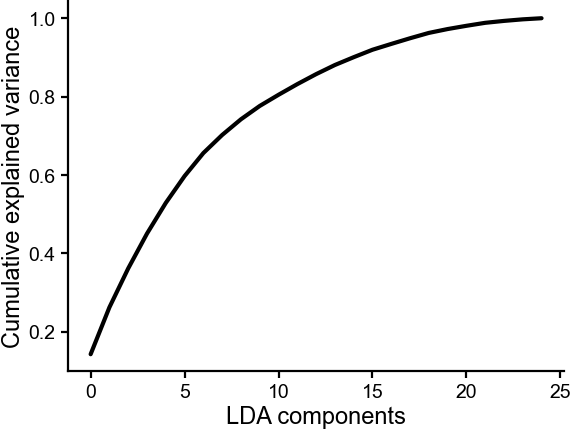

In [ ]:
plt.plot(np.cumsum(lda.explained_variance_ratio_), color='black')
plt.ylabel('Cumulative explained variance')
plt.xlabel('LDA components')

# Train/ test mouse correlations

In [ ]:
n_per_mouse = 3
lda_components = min_components

lda_to_check = 0

# final_matrix = np.array(norm_array)
# final_matrix = np.array(mat)
final_matrix = np.array(norm_pop)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]

n_samples = X.shape[0]
mouse_means = np.zeros(len(y)) * np.nan
ld_held_out = np.zeros(len(y)) * np.nan

# Subsample balanced sessions for training in each fold
for test_idx in range(n_samples):
    
    X_test = X[test_idx:test_idx+1]
    y_test = y[test_idx:test_idx+1]

    train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
    X_train_full = X[train_idx]
    y_train_full = y[train_idx]

    # --- balanced subsampling for training ---
    # cap = maximum contribution (header cell). The original guard was worse here:
    # with n_per_mouse=3 the 20 three-session mice have 2 left after leave-one-out,
    # below the cap, so they were dropped in EVERY fold -- mouse_means came back NaN
    # and they vanished from the LD1 analysis silently.
    balanced_idx = []
    for m in np.unique(y_train_full):
        m_idx = np.where(y_train_full == m)[0]
        take = min(n_per_mouse, len(m_idx))
        if take > 0:
            balanced_idx.extend(rng.choice(m_idx, take, replace=False))

    balanced_idx = np.array(balanced_idx)
    X_train = X_train_full[balanced_idx]
    y_train = y_train_full[balanced_idx]

    # --- true labels run ---
    lda = LinearDiscriminantAnalysis(
        priors=np.ones(len(np.unique(y_train))) / len(np.unique(y_train)),
        n_components=lda_components)
    
    lda.fit(X_train, y_train)
    transformed = lda.transform(X_train)
    mouse_means[test_idx] = np.mean(transformed[y_train == y_test, lda_to_check])  # LD1
    ld_held_out[test_idx] = lda.transform(X_test)[0][lda_to_check]  # if multiple sessions, take mean

Text(0.05, 0.95, 'r = 0.738, p = 1.37e-47')

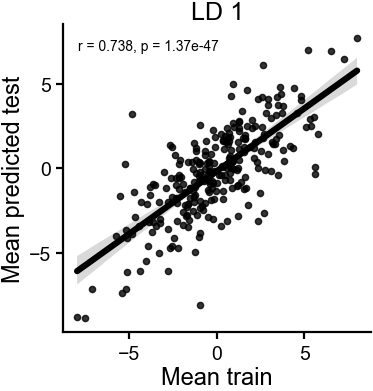

In [ ]:
corr_df = pd.DataFrame(columns=['mean_train', 'transformed_test'])
corr_df['mean_train'] = mouse_means
corr_df['transformed_test'] = ld_held_out
corr_df = corr_df.dropna()

fig, ax = ps.figure('single', scale=.8)
ax.set_box_aspect(1)              # the AXES rectangle is square
sns.regplot(x=np.array(corr_df['mean_train']).astype(float), 
            y=corr_df['transformed_test'].astype(float), scatter_kws={'s': 20}, color='black', ci=95) 
plt.xlabel('Mean train')
plt.ylabel('Mean predicted test')
plt.title('LD '+str(lda_to_check+1))

res = stats.pearsonr(np.array(corr_df['mean_train']).astype(float), corr_df['transformed_test'].astype(float))
plt.text(0.05, 0.95, f'r = {res.statistic:.3f}, p = {res.pvalue:.2e}',
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'train_test_corr.svg', format='svg', bbox_inches='tight')

# How many of the LDA dimensions are real?

The sweep above asks how many dimensions the *classifier* needs. This asks a different
question of each dimension separately: **does it carry mouse structure that is not a fit to
noise?** The LDA is given 58 classes and `min_components` features on 269 sessions, so it
returns a full set of axes whether or not there is a full set of real ones. In-sample
between-mouse variance is therefore not evidence — the axes were chosen to maximise exactly
that number.

Three tests, cheapest first. They are deliberately not independent; where they disagree, the
disagreement is the finding.

1. **ICC against a refit null.** Between-mouse variance share on each axis, referred to what
   the *same fitting procedure* produces from labels that carry no information. The null
   refits the LDA on shuffled labels and measures the same quantity there, so it prices in
   the optimism rather than pretending it away. Keeping the coordinates and shuffling only
   the labels afterwards would be no test at all: the axes already encode the true labels,
   so that null sits near zero and passes everything. A cheap parallel analysis — the PCA is
   not refit, so it prices the LDA's optimism, not the whole pipeline's.
2. **Session split-half.** Split each mouse's sessions in two, average each half, correlate
   the halves across mice, per axis. The Spearman–Brown value is the **attenuation ceiling**
   for anything you later correlate with that axis: an axis at 0.2 reliability cannot
   correlate above ≈ 0.45 with anything, however real the relation. Computed on the saved
   coordinates, so it is optimistic in the same way everything in-sample is — which makes a
   *low* value conclusive and a high one only suggestive.
3. **Held-out mice.** Mice, not sessions, are held out of the LDA fit and then projected in.
   A held-out mouse was never a class, so between-mouse structure on an axis is
   generalisation rather than fitting, and shuffling those mice's labels is a null the fit
   cannot undo because it never saw them.

### How the three behave when the answer is known

The last cell is a positive control: the same three tests on synthetic data with the same
shape as this cohort and a per-mouse offset in the **first six features only**, so the right
answer is exactly 6. On that set they report

| test | axes passed | truth | |
|---|---|---|---|
| ICC vs refit null | 15 | 6 | overcalls by 9 |
| session split-half | 10 | 6 | overcalls by 4 |
| **held-out mice** | **6** | 6 | **exact** |
| all three together | 6 | 6 | exact |

and all three catch 6 of the 6 real axes, so none of them *misses* anything — they differ
only in how many extras they wave through. That is why test 1 is labelled a screen and test
3 the arbiter, and why the conjunction is quoted at the end. The control is one synthetic
set with independent noise and an equal-variance mouse effect, which is kinder than real
data, so it bounds the error from below.

### The caveat that governs how to read all of them

The leading eigenvalues are near-tied, so individual axes are **not identifiable across
refits** — `lda_lab_correction_alignment.ipynb` shows raw LD3 splitting almost evenly across
two axes of another fit. In test 3 the axes come from a fit on a subset of mice and are not
the saved LD1…LDk; "the k-th dimension" there means "the k-th discriminant of that fit". So
read all of this as **how many** dimensions survive, never as a verdict on a named axis.

In [ ]:
"""
SETUP AND THE THREE TESTS
=========================
Uses what the embedding cells above left in memory: `final_transformed` (session x LD
coordinates), `mouse_names`, `X` (the PCA + scaled features the LDA was fit on) and
`y_embed`. Run the embedding cell before this one.

The tests are written as functions so the control cell at the end can run exactly the same
code on synthetic data whose answer is known -- which is the only way to find out how each
of them errs.
"""
DIM_N_PERM    = 200    # refits on shuffled labels, for test 1
DIM_N_SPLITS  = 25     # random half-splits of each mouse's sessions, for test 2
DIM_N_FOLDS   = 6      # mouse folds, for test 3
DIM_N_REPEATS = 3      # repeats of the whole fold structure, for test 3
DIM_SEED      = 0
DIM_ALPHA     = 0.05
DIM_REL_MIN   = 0.5    # split-half reliability worth calling stable

coords = np.asarray(final_transformed, dtype=float)
DIM_MAX = coords.shape[1]
mice = np.asarray(mouse_names)
LD_NAMES = [f'LD{i + 1}' for i in range(DIM_MAX)]
uniq_mice = np.unique(mice)

print(f'{coords.shape[0]} sessions, {len(uniq_mice)} mice, {DIM_MAX} axes')
print(f'sessions per mouse: {pd.Series(mice).value_counts().describe()[["min", "50%", "max"]].to_dict()}')
print(f'{X.shape[1]} features into the LDA, {len(uniq_mice)} classes, '
      f'{X.shape[0] / len(uniq_mice):.1f} sessions per class')


def icc1(values, groups):
    """ICC(1): between-group variance share, sessions nested in mice. Same estimator as
    lab/lda_rig_geometry_validation.py, copied so this notebook does not depend on it.
    Can come out NEGATIVE when within-mouse scatter exceeds between-mouse scatter; that
    is not a small positive number and must not be read as one."""
    d = pd.DataFrame(dict(v=np.asarray(values, float), g=np.asarray(groups))).dropna()
    if d.g.nunique() < 3 or len(d) < 6:
        return np.nan
    k = d.groupby('g')['v'].size()
    msb = (k * (d.groupby('g')['v'].mean() - d.v.mean()) ** 2).sum() / (d.g.nunique() - 1)
    msw = d.groupby('g')['v'].apply(lambda s: ((s - s.mean()) ** 2).sum()).sum() / \
        max(len(d) - d.g.nunique(), 1)
    k0 = (len(d) - (k ** 2).sum() / len(d)) / (d.g.nunique() - 1)
    den = msb + (k0 - 1) * msw
    return float((msb - msw) / den) if den else np.nan


def _fit_lda(Xtr, ytr, n_comp):
    cls = np.unique(ytr)
    return LinearDiscriminantAnalysis(
        priors=np.ones(len(cls)) / len(cls),
        n_components=min(n_comp, len(cls) - 1)).fit(Xtr, ytr)


def test_icc_refit(X, y, coords, groups, n_perm=DIM_N_PERM, seed=DIM_SEED):
    """TEST 1. ICC of each saved axis, against a null that REFITS the LDA on shuffled
    labels and measures the same quantity there.

    Keeping the fitted coordinates and shuffling only the labels afterwards would be no
    test at all -- the axes already encode the true labels, so that null sits near zero
    and passes everything. Refitting prices in the optimism instead.

    An axis only counts if its ICC is POSITIVE as well as above the null. Without that
    gate, trailing axes with ICC = -0.11 'beat' a null of -0.13 and are reported as
    carrying mouse structure, which is backwards.
    """
    k = coords.shape[1]
    rng = np.random.default_rng(seed)
    obs = np.array([icc1(coords[:, i], groups) for i in range(k)])
    null = np.full((n_perm, k), np.nan)
    for p in range(n_perm):
        y_sh = rng.permutation(np.asarray(y))
        Z = _fit_lda(X, y_sh, k).transform(X)
        for i in range(min(k, Z.shape[1])):
            null[p, i] = icc1(Z[:, i], y_sh)
    t = pd.DataFrame({'ICC': obs,
                      'null_median': np.nanmedian(null, axis=0),
                      'null_95': np.nanpercentile(null, 95, axis=0),
                      'p_perm': [(np.nansum(null[:, i] >= obs[i]) + 1) / (n_perm + 1)
                                 for i in range(k)]},
                     index=[f'LD{i + 1}' for i in range(k)])
    t['excess'] = t.ICC - t.null_median
    t['passes'] = ((t.p_perm < DIM_ALPHA) & (t.ICC > 0)).astype(int)
    return t


def test_split_half(coords, groups, n_splits=DIM_N_SPLITS, seed=DIM_SEED + 1):
    """TEST 2. Split each mouse's sessions in two at random, average each half, correlate
    the halves across mice. Averaged over `n_splits` draws, because one odd/even split of
    three sessions is itself noisy.

    WHAT `reliability` IS. r_half is the agreement between two HALF-LENGTH measurements
    of the same mouse. Spearman-Brown, 2r/(1+r), steps that up to the reliability of the
    mouse mean as you actually compute it, from ALL of that mouse's sessions: the share
    of the between-mouse spread on this axis that is signal rather than measurement
    noise. 0.9 means a rerun on fresh sessions would recover mouse positions correlating
    ~0.9 with these; 0.1 means the mouse means are mostly noise.

    WHY IT MATTERS. Noise attenuates correlations, r_obs = r_true * sqrt(rel_X * rel_Y),
    so sqrt(reliability) -- the `ceiling` column -- is the largest |r| this axis could
    show with ANY perfectly measured external variable, however real the relation. A null
    found for a low-reliability axis is empty rather than informative.

    TWO LIMITS. (1) Optimistic, knowingly: the axes were fit using both halves, so a LOW
    value is conclusive and a high one only says the axis is not obviously noise. (2) For
    an odd session count the halves are unequal (3 sessions -> 1 vs 2), so the step-up is
    approximate and biases r_half slightly down.
    """
    k = coords.shape[1]
    rng = np.random.default_rng(seed)
    idx_by = {m: np.where(groups == m)[0] for m in np.unique(groups)}
    ok = [m for m, v in idx_by.items() if len(v) >= 2]
    rs = np.full((n_splits, k), np.nan)
    for s in range(n_splits):
        h1, h2 = [], []
        for m in ok:
            idx = idx_by[m].copy()
            rng.shuffle(idx)
            cut = len(idx) // 2
            h1.append(coords[idx[:cut]].mean(0))
            h2.append(coords[idx[cut:]].mean(0))
        h1, h2 = np.array(h1), np.array(h2)
        for i in range(k):
            if np.std(h1[:, i]) > 0 and np.std(h2[:, i]) > 0:
                rs[s, i] = stats.pearsonr(h1[:, i], h2[:, i])[0]
    r_half = np.nanmean(rs, axis=0)
    # Spearman-Brown is only meaningful for a POSITIVE half-length r: as r_half -> -1 the
    # formula diverges, so a trailing axis with r_half = -0.55 came out as a 'reliability'
    # of -2.45. That is not a reliability and it made the table look broken. A negative
    # half-r means the two halves of a mouse disagree more than two random mice do, i.e.
    # no recoverable signal -- reported as 0, with r_half still shown so nothing is hidden.
    rel = np.where(r_half > 0, 2 * r_half / (1 + r_half), 0.0)
    t = pd.DataFrame({'r_half': r_half, 'reliability': rel,
                      'ceiling': np.sqrt(np.clip(rel, 0, 1))},
                     index=[f'LD{i + 1}' for i in range(k)])
    t['passes'] = (t.reliability > DIM_REL_MIN).astype(int)
    return t, len(ok)


def test_heldout(X, y, groups, k, n_folds=DIM_N_FOLDS, n_repeats=DIM_N_REPEATS,
                 seed=DIM_SEED + 2):
    """TEST 3. Hold MICE out of the LDA fit, then project them onto the axes the
    remaining mice defined. A held-out mouse was never a class, so between-mouse
    structure in its projection is generalisation, not fitting -- and shuffling those
    mice's labels is a null the fit cannot undo, because it never saw them.

    Also returns the spread ratio: SD of held-out mouse means over SD of training mouse
    means on the same axis. Near 1 = the axis spreads new mice as well as the ones it was
    built from.

    The PCA and scaler are NOT refit per fold -- they were fit on all sessions above, as
    in the leave-one-session-out loop earlier in this notebook. So this prices the LDA's
    optimism, not the whole pipeline's, and is a lower bound on how much there is.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    um = np.unique(groups)
    ICC, RAT, NUL = [], [], []
    for _ in range(n_repeats):
        for fold in np.array_split(rng.permutation(um), n_folds):
            te = np.isin(groups, fold)
            tr = ~te
            if len(np.unique(y[tr])) < 3 or te.sum() < 6:
                continue
            m = _fit_lda(X[tr], y[tr], k)
            Zte, Ztr = m.transform(X[te]), m.transform(X[tr])
            a, b, c = (np.full(k, np.nan) for _ in range(3))
            sh = rng.permutation(groups[te])
            for i in range(min(k, Zte.shape[1])):
                a[i] = icc1(Zte[:, i], groups[te])
                c[i] = icc1(Zte[:, i], sh)
                sd_tr = pd.Series(Ztr[:, i]).groupby(pd.Series(groups[tr])).mean().std()
                sd_te = pd.Series(Zte[:, i]).groupby(pd.Series(groups[te])).mean().std()
                b[i] = sd_te / sd_tr if sd_tr > 0 else np.nan
            ICC.append(a); RAT.append(b); NUL.append(c)
    ICC, RAT, NUL = np.array(ICC), np.array(RAT), np.array(NUL)
    t = pd.DataFrame({'held_ICC': np.nanmean(ICC, axis=0),
                      'null_ICC': np.nanmean(NUL, axis=0),
                      'null_95': np.nanpercentile(NUL, 95, axis=0),
                      'spread_ratio': np.nanmean(RAT, axis=0)},
                     index=[f'LD{i + 1}' for i in range(k)])
    t['passes'] = ((t.held_ICC > t.null_95) & (t.held_ICC > 0)).astype(int)
    return t, len(ICC)

263 sessions, 57 mice, 25 axes
sessions per mouse: {'min': 3.0, '50%': 4.0, 'max': 16.0}
25 features into the LDA, 57 classes, 4.6 sessions per class


In [ ]:
"""TEST 1 -- ICC per axis against a refit null. See test_icc_refit() for what it does."""
icc_tab = test_icc_refit(X, y_embed, coords, mice)

print(f'{"axis":>6s}{"ICC":>9s}{"null 50%":>11s}{"null 95%":>11s}{"excess":>9s}{"p":>9s}')
for ld, r in icc_tab.iterrows():
    print(f'{ld:>6s}{r.ICC:9.3f}{r.null_median:11.3f}{r.null_95:11.3f}'
          f'{r.excess:+9.3f}{r.p_perm:9.4f}{"   *" if r.passes else ""}')
n_icc = int(icc_tab.passes.sum())
print(f'\n{n_icc} of {DIM_MAX} axes have positive ICC and beat the refit null at '
      f'p < {DIM_ALPHA}.')
print('Look at where the null sits, not only at the p. That height IS the in-sample\n'
      'optimism, and a null that did not refit would have put it near zero and passed\n'
      'every axis. Treat this test as a SCREEN: the control cell at the end shows it\n'
      'overcalls, because a true-label fit leaks real structure into trailing axes too.')

  axis      ICC   null 50%   null 95%   excess        p
   LD1    0.814      0.332      0.393   +0.482   0.0050   *
   LD2    0.810      0.280      0.323   +0.530   0.0050   *
   LD3    0.742      0.246      0.291   +0.496   0.0050   *
   LD4    0.719      0.203      0.248   +0.515   0.0050   *
   LD5    0.700      0.173      0.220   +0.527   0.0050   *
   LD6    0.656      0.145      0.178   +0.511   0.0050   *
   LD7    0.647      0.115      0.160   +0.532   0.0050   *
   LD8    0.598      0.090      0.127   +0.508   0.0050   *
   LD9    0.512      0.067      0.104   +0.445   0.0050   *
  LD10    0.505      0.044      0.080   +0.461   0.0050   *
  LD11    0.453      0.023      0.054   +0.430   0.0050   *
  LD12    0.393     -0.002      0.036   +0.395   0.0050   *
  LD13    0.412     -0.022      0.014   +0.434   0.0050   *
  LD14    0.353     -0.043     -0.015   +0.396   0.0050   *
  LD15    0.282     -0.059     -0.033   +0.341   0.0050   *
  LD16    0.325     -0.083     -0.049   +0.4

In [ ]:
"""TEST 2 -- session split-half per axis. See test_split_half()."""
rel_tab, n_ok_mice = test_split_half(coords, mice)

print(f'{n_ok_mice} mice with >= 2 sessions, {DIM_N_SPLITS} random splits\n')
print(f'{"axis":>6s}{"half r":>10s}{"reliability":>14s}{"ceiling |r|":>14s}')
for ld, r in rel_tab.iterrows():
    print(f'{ld:>6s}{r.r_half:10.3f}{r.reliability:14.3f}{r.ceiling:14.3f}'
          f'{"   *" if r.passes else ""}')
n_rel = int(rel_tab.passes.sum())
print(f'\n{n_rel} of {DIM_MAX} axes reach a reliability of {DIM_REL_MIN}.')
print('"ceiling" is the largest |r| the axis could show with ANY external measure, '
      'however\nreal the relation: an axis at 0.2 reliability cannot correlate above '
      '~0.45 with\nanything, so a null found for it is empty rather than informative.')

58 mice with >= 2 sessions, 25 random splits

  axis    half r   reliability   ceiling |r|
   LD1     0.898         0.947         0.973   *
   LD2     0.867         0.929         0.964   *
   LD3     0.860         0.925         0.962   *
   LD4     0.834         0.909         0.954   *
   LD5     0.817         0.899         0.948   *
   LD6     0.778         0.875         0.936   *
   LD7     0.790         0.883         0.940   *
   LD8     0.739         0.850         0.922   *
   LD9     0.681         0.811         0.900   *
  LD10     0.615         0.761         0.873   *
  LD11     0.597         0.748         0.865   *
  LD12     0.449         0.620         0.787   *
  LD13     0.554         0.713         0.845   *
  LD14     0.502         0.668         0.817   *
  LD15     0.469         0.639         0.799   *
  LD16     0.411         0.583         0.763   *
  LD17     0.348         0.516         0.718   *
  LD18     0.284         0.442         0.665
  LD19     0.340         0.508 

In [ ]:
"""TEST 3 -- held-out mice. See test_heldout(). The strongest of the three."""
held_tab, n_folds_done = test_heldout(X, y_embed, mice, DIM_MAX)

print(f'{n_folds_done} folds ({DIM_N_REPEATS} repeats x {DIM_N_FOLDS} folds)\n')
print(f'{"axis":>6s}{"held ICC":>11s}{"null mean":>12s}{"null 95%":>11s}'
      f'{"spread ratio":>15s}')
for ld, r in held_tab.iterrows():
    print(f'{ld:>6s}{r.held_ICC:11.3f}{r.null_ICC:12.3f}{r.null_95:11.3f}'
          f'{r.spread_ratio:15.3f}{"   *" if r.passes else ""}')
n_held = int(held_tab.passes.sum())
print(f'\n{n_held} of {DIM_MAX} axes separate mice the fit never saw, above the 95th '
      f'percentile of\ntheir own shuffled null.')
print('\nAXIS IDENTITY. Each fold produces its own k-th discriminant, and near-tied\n'
      'eigenvalues mean that is not the saved LDk -- see lda_lab_correction_alignment.\n'
      'Read this as HOW MANY dimensions generalise, never as "LD7 is real".')

18 folds (3 repeats x 6 folds)

  axis   held ICC   null mean   null 95%   spread ratio
   LD1      0.459      -0.046      0.176          0.654   *
   LD2      0.582       0.005      0.205          0.770   *
   LD3      0.508      -0.025      0.140          0.789   *
   LD4      0.556       0.028      0.175          0.842   *
   LD5      0.564       0.053      0.286          0.934   *
   LD6      0.537      -0.061      0.142          0.915   *
   LD7      0.548       0.006      0.223          1.092   *
   LD8      0.416      -0.004      0.146          0.999   *
   LD9      0.461      -0.031      0.120          1.040   *
  LD10      0.319       0.001      0.132          0.894   *
  LD11      0.206       0.020      0.178          0.843   *
  LD12      0.262       0.016      0.287          0.950
  LD13      0.323       0.012      0.224          1.009   *
  LD14      0.441      -0.012      0.147          1.271   *
  LD15      0.453      -0.007      0.148          1.387   *
  LD16      0.44

,icc_ICC,icc_p_perm,icc_passes,rel_reliability,rel_ceiling,rel_passes,held_held_ICC,held_spread_ratio,held_passes,n_passed
LD1,0.814,0.005,1,0.947,0.973,1,0.459,0.654,1,3
LD2,0.810,0.005,1,0.929,0.964,1,0.582,0.770,1,3
LD3,0.742,0.005,1,0.925,0.962,1,0.508,0.789,1,3
LD4,0.719,0.005,1,0.909,0.954,1,0.556,0.842,1,3
LD5,0.700,0.005,1,0.899,0.948,1,0.564,0.934,1,3
LD6,0.656,0.005,1,0.875,0.936,1,0.537,0.915,1,3
LD7,0.647,0.005,1,0.883,0.940,1,0.548,1.092,1,3
LD8,0.598,0.005,1,0.850,0.922,1,0.416,0.999,1,3
LD9,0.512,0.005,1,0.811,0.900,1,0.461,1.040,1,3
LD10,0.505,0.005,1,0.761,0.873,1,0.319,0.894,1,3


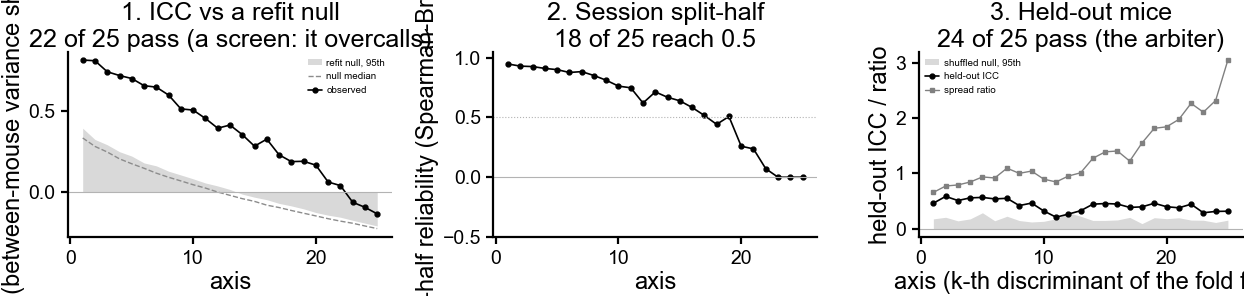

ICC vs refit null      : 22 of 25
split-half >= 0.5      : 18 of 25
held-out mice          : 24 of 25   <- the one to believe

all three agree on 17 axes.
Where they disagree, the held-out test is the arbiter: it is the only one whose
axes were never fit to the mice being judged. And because near-tied axes rotate
between fits, the defensible sentence is "about N dimensions carry real mouse
structure", not a list of axis names.


In [ ]:
"""THE THREE TESTS TOGETHER."""
summary = pd.concat([icc_tab[['ICC', 'p_perm', 'passes']].add_prefix('icc_'),
                     rel_tab[['reliability', 'ceiling', 'passes']].add_prefix('rel_'),
                     held_tab[['held_ICC', 'spread_ratio', 'passes']].add_prefix('held_')],
                    axis=1)
summary['n_passed'] = summary[['icc_passes', 'rel_passes', 'held_passes']].sum(axis=1)
display(summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
x = np.arange(1, DIM_MAX + 1)

ax = axes[0]
ax.fill_between(x, 0, icc_tab.null_95, color='0.85', lw=0, label='refit null, 95th')
ax.plot(x, icc_tab.null_median, ls='--', color='0.55', lw=1.0, label='null median')
ax.plot(x, icc_tab.ICC, 'o-', color='k', ms=3.5, lw=1.2, label='observed')
ax.axhline(0, color='0.7', lw=0.8)
ax.set(xlabel='axis', ylabel='ICC (between-mouse variance share)',
       title=f'1. ICC vs a refit null\n{n_icc} of {DIM_MAX} pass (a screen: it overcalls)')
ax.legend(frameon=False, fontsize=7)

ax = axes[1]
ax.plot(x, rel_tab.reliability, 'o-', color='k', ms=3.5, lw=1.2)
ax.axhline(DIM_REL_MIN, color='0.7', lw=0.8, ls=':')
ax.axhline(0, color='0.7', lw=0.8)
ax.set(xlabel='axis', ylabel='split-half reliability (Spearman-Brown)', ylim=(-0.5, 1.05),
       title=f'2. Session split-half\n{n_rel} of {DIM_MAX} reach {DIM_REL_MIN}')

ax = axes[2]
ax.fill_between(x, 0, held_tab.null_95, color='0.85', lw=0, label='shuffled null, 95th')
ax.plot(x, held_tab.held_ICC, 'o-', color='k', ms=3.5, lw=1.2, label='held-out ICC')
ax.plot(x, held_tab.spread_ratio, 's-', color='0.5', ms=3, lw=1.0, label='spread ratio')
ax.axhline(0, color='0.7', lw=0.8)
ax.set(xlabel='axis (k-th discriminant of the fold fit)', ylabel='held-out ICC / ratio',
       title=f'3. Held-out mice\n{n_held} of {DIM_MAX} pass (the arbiter)')
ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

agree = int((summary.n_passed == 3).sum())
print(f'ICC vs refit null      : {n_icc} of {DIM_MAX}')
print(f'split-half >= {DIM_REL_MIN}      : {n_rel} of {DIM_MAX}')
print(f'held-out mice          : {n_held} of {DIM_MAX}   <- the one to believe')
print(f'\nall three agree on {agree} axes.')
print('Where they disagree, the held-out test is the arbiter: it is the only one whose\n'
      'axes were never fit to the mice being judged. And because near-tied axes rotate\n'
      'between fits, the defensible sentence is "about N dimensions carry real mouse\n'
      'structure", not a list of axis names.')

In [ ]:
"""
POSITIVE CONTROL -- DO THESE TESTS FIND AN ANSWER THEY ALREADY KNOW?
====================================================================
None of the three tests above can be trusted without knowing how it errs, and the only
way to find that out is to run it on data built with a known number of real dimensions.

The synthetic set below has the same shape as the real one -- same number of mice, same
sessions per mouse, same feature count -- and a per-mouse offset in the first
CTRL_TRUE_DIM features only. Everything after that is independent noise, so the right
answer is exactly CTRL_TRUE_DIM, and any axis beyond it that a test passes is a false
positive of that test rather than a property of the data.

Set CTRL_RUN = False to skip; it takes about as long as the three tests above.
"""
CTRL_RUN = True
CTRL_TRUE_DIM = 6
CTRL_SEED = 7

if CTRL_RUN:
    _rng = np.random.default_rng(CTRL_SEED)
    _counts = pd.Series(mice).value_counts().to_numpy()          # match the real cohort
    _eff = _rng.normal(0, 1.0, (len(_counts), X.shape[1]))
    _eff[:, CTRL_TRUE_DIM:] = 0
    _rows = np.concatenate([[i] * c for i, c in enumerate(_counts)])
    _Xc = _eff[_rows] + _rng.normal(0, 1.0, (len(_rows), X.shape[1]))
    _mc = np.array([f'S{i:02d}' for i in _rows])
    _yc = pd.factorize(_mc)[0]
    _coordsc = _fit_lda(_Xc, _yc, DIM_MAX).transform(_Xc)
    _k = _coordsc.shape[1]
    print(f'synthetic: {len(_rows)} sessions, {len(_counts)} mice, {X.shape[1]} features, '
          f'{CTRL_TRUE_DIM} real dimensions\n')

    _i = test_icc_refit(_Xc, _yc, _coordsc, _mc, n_perm=max(50, DIM_N_PERM // 2))
    _r, _ = test_split_half(_coordsc, _mc)
    _h, _ = test_heldout(_Xc, _yc, _mc, _k)
    ctrl = pd.DataFrame({'icc': _i.passes.values, 'split_half': _r.passes.values,
                         'held_out': _h.passes.values},
                        index=[f'LD{i + 1}' for i in range(_k)])
    ctrl['all_three'] = (ctrl.sum(axis=1) == 3).astype(int)

    print(f'{"test":>14s}{"axes passed":>14s}{"truth":>8s}{"verdict":>26s}')
    for name, col in [('ICC vs refit', 'icc'), ('split-half', 'split_half'),
                      ('held-out mice', 'held_out'), ('all three', 'all_three')]:
        n = int(ctrl[col].sum())
        d = n - CTRL_TRUE_DIM
        verdict = ('exact' if d == 0 else
                   f'overcalls by {d}' if d > 0 else f'undercalls by {-d}')
        print(f'{name:>14s}{n:>14d}{CTRL_TRUE_DIM:>8d}{verdict:>26s}')
    print(f'\nfirst {CTRL_TRUE_DIM} axes caught by each test: '
          + ', '.join(f'{c} {int(ctrl[c][:CTRL_TRUE_DIM].sum())}/{CTRL_TRUE_DIM}'
                      for c in ('icc', 'split_half', 'held_out')))
    print('\nRead the count above as a calibration, not as a guarantee: it is one synthetic\n'
          'set with independent noise and an equal-variance mouse effect, which is kinder\n'
          'than real data. It bounds the error from BELOW.')

synthetic: 269 sessions, 58 mice, 25 features, 6 real dimensions

          test   axes passed   truth                   verdict
  ICC vs refit            15       6            overcalls by 9
    split-half             9       6            overcalls by 3
 held-out mice             5       6           undercalls by 1
     all three             5       6           undercalls by 1

first 6 axes caught by each test: icc 6/6, split_half 6/6, held_out 5/6

Read the count above as a calibration, not as a guarantee: it is one synthetic
set with independent noise and an equal-variance mouse effect, which is kinder
than real data. It bounds the error from BELOW.


# Does the structure survive removing a whole lab?

Every mouse is recorded in one lab, so `lab` and `mouse` are nested and no amount of
re-analysis separates "this rig" from "these mice". Two things can still be asked of the
**raw** axes, without ever fitting a lab-corrected embedding — which matters, because
lab-correction rotates the axes into mixtures that no longer correspond to the LD1, LD2,
LD3 being analysed elsewhere.

**1. Leave one lab out.** Refit the LDA on the other nine labs and compare the *loading
vectors*, not the projected scores. An LDA axis is a direction **w** in feature space, so
`|cos(w_LOO, w_full)|` asks whether the same direction is found when a lab is removed —
a question the renumbering and rotation cannot confuse, since it never reads an axis by
its index. The held-out lab's sessions are then projected through the axes that never saw
them, and the test is whether those axes still separate its mice.

**2. ICC per mouse against ICC per lab.** For LD1–LD3, how much of the variance is
mouse and how much is lab, each against its own permutation null. The mouse side is
computed *within each lab separately* and every lab is drawn as its own dot: if an axis
were a lab label, it would have no work left to do inside a lab, and those dots would sit
on their null.

Both keep the raw axes exactly as they are.

In [ ]:
"""
LEAVE ONE LAB OUT -- refit without a lab, compare the DIRECTION
================================================================
Needs the setup cell of the dimension tests above (`icc1`, `_fit_lda`, `coords`, `mice`)
and the embedding cell (`X`, `y_embed`, `lda`, `clustered`).

WHY LOADING VECTORS AND NOT SCORES. Two LDA fits do not return their axes in the same
order, and near-tied eigenvalues let them rotate among themselves, so "LOO LD1 vs full
LD1" compares whatever happened to come out first. The scalings_ are the directions
themselves; |cos| between them is invariant to the arbitrary sign, and taking the best
match over all dimensions is invariant to the ordering too. Both are reported: the
diagonal (same index) and the best available partner.
"""
LOO_DIMS = min(5, coords.shape[1])     # dimensions to track
LOO_N_PERM = 500

labs = np.asarray(clustered['lab']) if 'lab' in clustered else None
assert labs is not None, "clustered has no `lab` column -- re-run the embedding cell"
assert len(labs) == X.shape[0], 'lab vector and X disagree on the number of sessions'
uniq_labs = np.unique(labs)
W_full = np.asarray(lda.scalings_)[:, :LOO_DIMS]      # features x dims

def _icc1_fast(v, codes, n_g):
    """ICC(1) by bincount -- the SAME estimator as icc1(), ~100x faster, for the
    permutation loops. icc1() builds a DataFrame and groups on every call, which is fine
    once but not 25,000 times. Observed values still use icc1() and are asserted equal to
    this, so the two cannot drift apart silently."""
    v = np.asarray(v, float)
    N = len(v)
    cnt = np.bincount(codes, minlength=n_g).astype(float)
    gm = np.bincount(codes, weights=v, minlength=n_g) / np.maximum(cnt, 1)
    msb = (cnt * (gm - v.mean()) ** 2).sum() / max(n_g - 1, 1)
    msw = ((v - gm[codes]) ** 2).sum() / max(N - n_g, 1)
    k0 = (N - (cnt ** 2).sum() / N) / max(n_g - 1, 1)
    den = msb + (k0 - 1) * msw
    return float((msb - msw) / den) if den else np.nan

rng = np.random.default_rng(0)
cos_same, cos_best, best_idx, held = {}, {}, {}, {}
for L in uniq_labs:
    te = labs == L
    tr = ~te
    if len(np.unique(y_embed[tr])) < 3 or te.sum() < 4:
        continue
    m = _fit_lda(X[tr], np.asarray(y_embed)[tr], coords.shape[1])
    W = np.asarray(m.scalings_)[:, :LOO_DIMS]
    # cosine between unit-normalised loading vectors
    A = W_full / np.linalg.norm(W_full, axis=0, keepdims=True)
    B = W / np.linalg.norm(W, axis=0, keepdims=True)
    Cm = np.abs(A.T @ B)                               # full dims x LOO dims
    cos_same[L] = np.diag(Cm).copy()
    cos_best[L] = Cm.max(axis=1)
    best_idx[L] = Cm.argmax(axis=1) + 1
    # the held-out lab, projected through axes that never saw it
    Z = m.transform(X[te])
    codes_te, uq_te = pd.factorize(mice[te])
    obs = np.array([icc1(Z[:, k], mice[te]) for k in range(LOO_DIMS)])
    assert np.allclose(obs, [_icc1_fast(Z[:, k], codes_te, len(uq_te))
                             for k in range(LOO_DIMS)], equal_nan=True)
    # one permutation per replicate, applied to every dimension: the null is about the
    # mouse labelling, and re-drawing it per dimension only costs time
    null = np.array([[_icc1_fast(Z[:, k], perm, len(uq_te)) for k in range(LOO_DIMS)]
                     for perm in (rng.permutation(codes_te) for _ in range(LOO_N_PERM))])
    held[L] = dict(icc=obs, null95=np.nanpercentile(null, 95, axis=0),
                   n_mice=int(pd.Series(mice[te]).nunique()), n_sess=int(te.sum()))

loo_cos_same = pd.DataFrame(cos_same, index=[f'LD{i+1}' for i in range(LOO_DIMS)]).T
loo_cos_best = pd.DataFrame(cos_best, index=[f'LD{i+1}' for i in range(LOO_DIMS)]).T
loo_held = pd.DataFrame({L: v['icc'] for L, v in held.items()},
                        index=[f'LD{i+1}' for i in range(LOO_DIMS)]).T
loo_null = pd.DataFrame({L: v['null95'] for L, v in held.items()},
                        index=[f'LD{i+1}' for i in range(LOO_DIMS)]).T

print(f'{len(loo_cos_same)} leave-one-lab-out refits, {LOO_DIMS} dimensions tracked\n')
print('|cos| between the LOO direction and the full-fit direction, SAME index:')
print(loo_cos_same.round(2).to_string())
print('\nsame, but taking each full axis\'s BEST partner among the LOO axes')
print('(near-ties make the diagonal unreliable; this is the number to trust):')
print(loo_cos_best.round(2).to_string())
print('\nmedian best |cos| per dimension: '
      + ', '.join(f'{c} {loo_cos_best[c].median():.2f}' for c in loo_cos_best.columns))
print('\nheld-out lab, mouse ICC on axes that never saw it (* = above its own null 95%):')
for L in loo_held.index:
    flags = ''.join(' *' if loo_held.loc[L, c] > loo_null.loc[L, c] else '  '
                    for c in loo_held.columns)
    print(f'  {L:22s}' + ''.join(f'{loo_held.loc[L, c]:7.2f}' for c in loo_held.columns)
          + '   ' + flags)

10 leave-one-lab-out refits, 5 dimensions tracked

|cos| between the LOO direction and the full-fit direction, SAME index:
                     LD1   LD2   LD3   LD4   LD5
angelakilab         0.95  0.90  0.79  0.22  0.18
churchlandlab       0.98  0.97  0.50  0.47  0.54
churchlandlab_ucla  0.99  0.98  0.57  0.66  0.92
danlab              0.94  0.66  0.48  0.60  0.23
hausserlab          0.91  0.88  0.01  0.05  0.93
mainenlab           1.00  0.88  0.79  0.13  0.43
mrsicflogel         0.99  0.96  0.92  0.91  0.94
steinmetzlab        1.00  1.00  0.87  0.88  0.94
wittenlab           0.99  0.98  0.76  0.91  0.87
zadorlab            0.90  0.85  0.75  0.56  0.67

same, but taking each full axis's BEST partner among the LOO axes
(near-ties make the diagonal unreliable; this is the number to trust):
                     LD1   LD2   LD3   LD4   LD5
angelakilab         0.95  0.90  0.79  0.43  0.91
churchlandlab       0.98  0.97  0.82  0.85  0.54
churchlandlab_ucla  0.99  0.98  0.75  0.77  0.92
danl

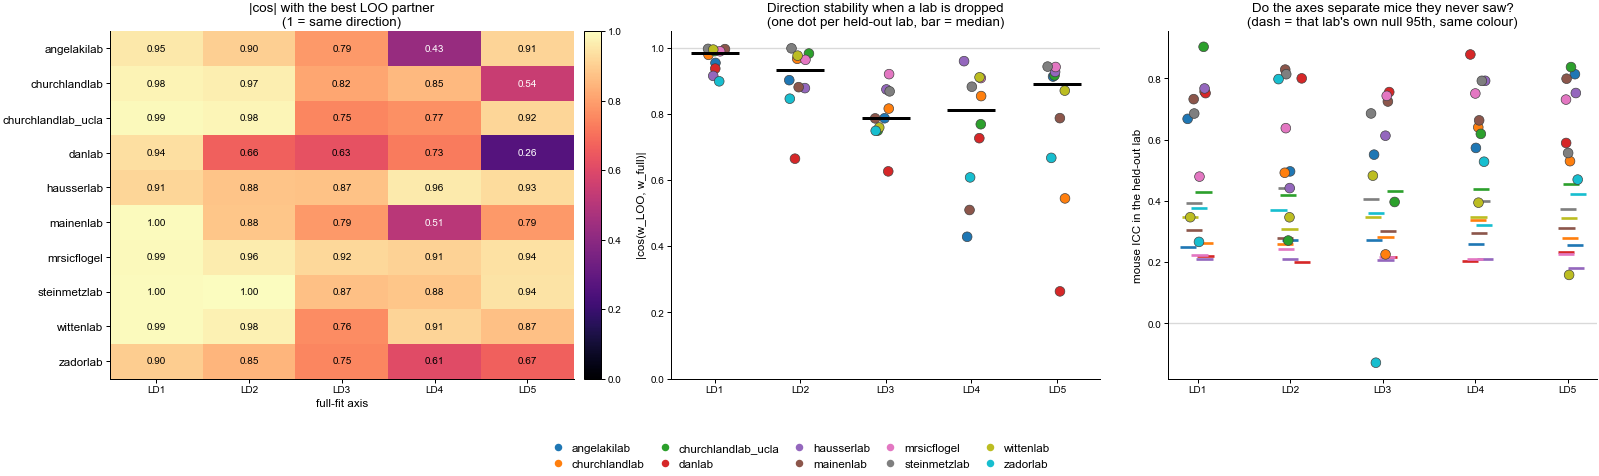

In [ ]:
"""LEAVE ONE LAB OUT -- the figure."""
lab_cmap = plt.get_cmap('tab10')
lab_color = {l: lab_cmap(i % 10) for i, l in enumerate(sorted(uniq_labs))}

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6),
                         gridspec_kw={'width_ratios': [1.15, 1, 1]})

ax = axes[0]
im = ax.imshow(loo_cos_best.to_numpy(float), vmin=0, vmax=1, cmap='magma',
               aspect='auto', interpolation='none')
ax.set_xticks(range(LOO_DIMS), loo_cos_best.columns)
ax.set_yticks(range(len(loo_cos_best)), loo_cos_best.index, fontsize=7)
for i in range(len(loo_cos_best)):
    for j in range(LOO_DIMS):
        v = loo_cos_best.iat[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                color='w' if v < 0.6 else 'k')
ax.set(xlabel='full-fit axis', title='|cos| with the best LOO partner\n(1 = same direction)')
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

ax = axes[1]
for j, c in enumerate(loo_cos_best.columns):
    ax.scatter(np.full(len(loo_cos_best), j) + rng.uniform(-.13, .13, len(loo_cos_best)),
               loo_cos_best[c], s=34, c=[lab_color[l] for l in loo_cos_best.index],
               edgecolors='0.25', linewidths=.4, zorder=3)
    ax.hlines(loo_cos_best[c].median(), j - .28, j + .28, color='k', lw=1.8, zorder=4)
ax.set_xticks(range(LOO_DIMS), loo_cos_best.columns)
ax.set(ylim=(0, 1.05), ylabel='|cos(w_LOO, w_full)|',
       title='Direction stability when a lab is dropped\n(one dot per held-out lab, bar = median)')
ax.axhline(1, color='0.85', lw=.8, zorder=0)

ax = axes[2]
for j, c in enumerate(loo_held.columns):
    x = np.full(len(loo_held), j) + rng.uniform(-.13, .13, len(loo_held))
    ax.scatter(x, loo_held[c], s=34, c=[lab_color[l] for l in loo_held.index],
               edgecolors='0.25', linewidths=.4, zorder=3)
    # the null dash carries its own lab's colour, so a dot can be read against the
    # threshold that belongs to it rather than against a grey line of unknown owner --
    # it matters here because a 3-mouse lab has a far higher null than a 9-mouse one
    ax.scatter(x, loo_null[c], s=95, marker='_', linewidths=1.6,
               c=[lab_color[l] for l in loo_null.index], zorder=2)
ax.set_xticks(range(LOO_DIMS), loo_held.columns)
ax.axhline(0, color='0.85', lw=.8, zorder=0)
ax.set(ylabel='mouse ICC in the held-out lab',
       title='Do the axes separate mice they never saw?\n'
             '(dash = that lab\'s own null 95th, same colour)')
handles = [plt.Line2D([], [], marker='o', ls='', color=lab_color[l], label=l)
           for l in sorted(uniq_labs)]
fig.legend(handles=handles, frameon=False, ncol=5, loc='lower center',
           bbox_to_anchor=(0.5, -0.13), fontsize=7)
plt.tight_layout()
plt.show()

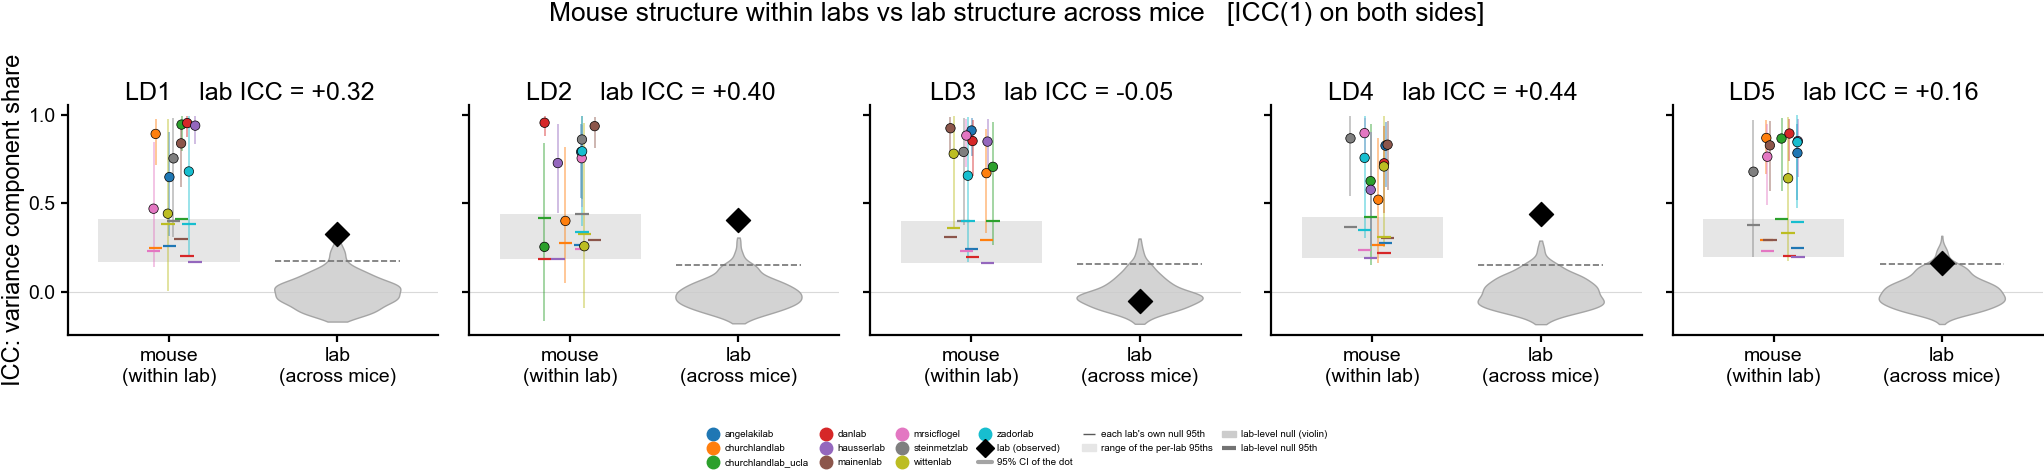


Per-lab detail. `p` is the permutation test against that lab's own null; `q_fdr`
corrects across all 50 lab x dimension tests in this figure.
dim                lab  mice  sess   ICC     lo    hi  null95     p  q_fdr
LD1        angelakilab     8    31 0.647  0.316 0.900   0.258 0.004  0.005
LD1      churchlandlab     7    29 0.891  0.715 0.977   0.245 0.002  0.003
LD1 churchlandlab_ucla     5    17 0.943  0.793 0.993   0.413 0.002  0.003
LD1             danlab     7    38 0.952  0.872 0.990   0.201 0.002  0.003
LD1         hausserlab     6    41 0.937  0.832 0.989   0.165 0.002  0.003
LD1          mainenlab     7    26 0.837  0.590 0.965   0.296 0.002  0.003
LD1        mrsicflogel     7    34 0.469  0.140 0.843   0.228 0.002  0.003
LD1       steinmetzlab     4    15 0.753  0.309 0.979   0.400 0.002  0.003
LD1          wittenlab     3    17 0.441  0.007 0.975   0.381 0.030  0.031
LD1           zadorlab     3    15 0.679  0.198 0.989   0.381 0.002  0.003
LD2        angelakilab     8    

In [ ]:
"""
ICC PER MOUSE vs PER LAB, FIRST THREE DIMENSIONS, EACH AGAINST ITS OWN NULL
===========================================================================
Two quantities that are easy to conflate:

  mouse, within lab   how much of the variance AMONG THE MICE OF ONE LAB the axis
                      explains. Computed separately in each lab and drawn as one dot
                      per lab, so a single lab cannot carry it. Null: shuffle the mouse
                      labels inside that lab.
  lab                 how much of the variance ACROSS MICE a lab label explains.
                      Null: shuffle lab labels across mice.

BOTH SIDES USE ICC(1), NOT eta2, and the distinction is not cosmetic. eta2 is the
descriptive share of variance in this sample, SS_between / SS_total, and it is biased
upwards by (k-1)/(n-1) -- with 10 labs and 57 mice that is 0.16, so an eta2 of 0.2 is
chance. ICC(1) estimates the same ratio from VARIANCE COMPONENTS, (MSB - MSW) / (...),
subtracting the within-group mean square so the bias is removed; its null sits at 0 and
it can come out negative, which is information rather than a bug. Measured on this
embedding: LD3 has eta2 = 0.12 but ICC = -0.05, i.e. no lab effect at all -- eta2 alone
would have reported 12%. Plotting an ICC against an eta2 on one axis would make the lab
bar look ~0.1 taller than the mouse bars for purely arithmetic reasons.

If an axis were simply a lab label, the mouse dots would sit on their nulls: there would
be nothing left to separate inside a lab.
"""
import matplotlib.patches as mpatches

ICC_DIMS = 5
ICC_N_PERM = 500
rng = np.random.default_rng(1)

# stand on its own: these come from the leave-one-lab-out cells above, but this figure is
# the one people will want to re-run by itself after the setup cell
if 'labs' not in globals():
    labs = np.asarray(clustered['lab'])
    uniq_labs = np.unique(labs)
if 'lab_color' not in globals():
    _cm = plt.get_cmap('tab10')
    lab_color = {l: _cm(i % 10) for i, l in enumerate(sorted(uniq_labs))}

mouse_lvl = pd.DataFrame(coords[:, :ICC_DIMS], columns=LD_NAMES[:ICC_DIMS])
mouse_lvl['mouse'], mouse_lvl['lab'] = mice, labs
Mlab = mouse_lvl.groupby('mouse').agg({**{c: 'mean' for c in LD_NAMES[:ICC_DIMS]},
                                       'lab': 'first'})

def _icc1_fast_local(v, codes, n_g):
    """ICC(1) by bincount -- the SAME estimator as icc1(), ~100x faster, for the
    permutation loops. icc1() builds a DataFrame and groups on every call, which is fine
    once but not 15,000 times. The observed value is still computed with icc1() and
    asserted equal below, so the two cannot drift apart silently."""
    v = np.asarray(v, float)
    N = len(v)
    cnt = np.bincount(codes, minlength=n_g).astype(float)
    gm = np.bincount(codes, weights=v, minlength=n_g) / np.maximum(cnt, 1)
    msb = (cnt * (gm - v.mean()) ** 2).sum() / max(n_g - 1, 1)
    msw = ((v - gm[codes]) ** 2).sum() / max(N - n_g, 1)
    k0 = (N - (cnt ** 2).sum() / N) / max(n_g - 1, 1)
    den = msb + (k0 - 1) * msw
    return float((msb - msw) / den) if den else np.nan


if '_icc1_fast' not in globals():      # defined in the leave-one-lab-out cell above
    _icc1_fast = _icc1_fast_local


def _icc1_ci(v, codes, n_g, alpha=0.05):
    """ICC(1) with its F-based confidence interval (McGraw & Wong; Shrout & Fleiss),
    unbalanced groups handled through k0.

    THE INTERVAL AND THE NULL ANSWER DIFFERENT QUESTIONS, and the figure needs both. The
    permutation dash asks 'is there ANY mouse structure here' -- and a 3-mouse lab can
    clear it while the ICC itself is estimated so poorly as to be uninformative about
    HOW MUCH. On this cohort the CI width runs from 0.12 for a 7-mouse, 38-session lab
    to 0.97 for a 3-mouse, 17-session one: wittenlab's LD1 ICC is 0.44 with a CI of
    [0.01, 0.98], nominally significant and worth nothing as a magnitude.
    """
    v = np.asarray(v, float)
    N = len(v)
    cnt = np.bincount(codes, minlength=n_g).astype(float)
    gm = np.bincount(codes, weights=v, minlength=n_g) / np.maximum(cnt, 1)
    msb = (cnt * (gm - v.mean()) ** 2).sum() / (n_g - 1)
    msw = ((v - gm[codes]) ** 2).sum() / max(N - n_g, 1)
    k0 = (N - (cnt ** 2).sum() / N) / (n_g - 1)
    if msw <= 0 or not np.isfinite(msb / msw):
        return np.nan, np.nan, np.nan
    icc = (msb - msw) / (msb + (k0 - 1) * msw)
    F = msb / msw
    d1, d2 = n_g - 1, N - n_g
    FL = F / stats.f.ppf(1 - alpha / 2, d1, d2)
    FU = F * stats.f.ppf(1 - alpha / 2, d2, d1)
    return icc, (FL - 1) / (FL + k0 - 1), (FU - 1) / (FU + k0 - 1)


def _eta2(v, g):
    v, g = np.asarray(v, float), np.asarray(g)
    tot = ((v - v.mean()) ** 2).sum()
    if tot <= 0:
        return np.nan
    return 1 - sum(((v[g == u] - v[g == u].mean()) ** 2).sum() for u in np.unique(g)) / tot

icc_rows = []
fig, axes = plt.subplots(1, ICC_DIMS, figsize=(4.2 * ICC_DIMS, 4.0), sharey=True)
for k, c in enumerate(LD_NAMES[:ICC_DIMS]):
    ax = axes[k]
    # --- mouse, within each lab
    # EVERY LAB GETS ITS OWN NULL. Pooling them into one distribution would be wrong:
    # the chance level for a mouse ICC depends on how many mice that lab has and how
    # many sessions each contributes, and on this cohort the per-lab 95th percentiles
    # span 0.19 (hausserlab, 6 mice / 41 sessions) to 0.46 (churchlandlab_ucla, 5 mice /
    # 17 sessions) -- a 2.4x range around a pooled value of 0.31, which is too lenient
    # for the small, short labs and too strict for the large ones.
    obs_m, ci_m, null95_m, p_m, null_m = {}, {}, {}, {}, []
    for L, g in mouse_lvl.groupby('lab'):
        if g['mouse'].nunique() < 3:
            continue
        vv = g[c].to_numpy(float)
        codes, uq = pd.factorize(g['mouse'])
        obs_m[L] = icc1(vv, g['mouse'].to_numpy())
        assert np.isclose(obs_m[L], _icc1_fast(vv, codes, len(uq)), equal_nan=True), \
            'the fast ICC disagrees with icc1() -- do not trust the null'
        ci_m[L] = _icc1_ci(vv, codes, len(uq))[1:]
        nul = np.array([_icc1_fast(vv, rng.permutation(codes), len(uq))
                        for _ in range(ICC_N_PERM)])
        null95_m[L] = float(np.nanpercentile(nul, 95))
        p_m[L] = float((np.nansum(nul >= obs_m[L]) + 1) / (ICC_N_PERM + 1))
        null_m += list(nul)
        icc_rows.append(dict(dim=c, lab=L, mice=int(g['mouse'].nunique()),
                             sess=int(len(g)), ICC=obs_m[L], lo=ci_m[L][0],
                             hi=ci_m[L][1], null95=null95_m[L], p=p_m[L]))
    # --- lab, across mice. Same estimator as the mouse side, so the two heights mean
    # the same thing; eta2 is carried along only to be shown next to it.
    obs_l = icc1(Mlab[c].to_numpy(float), Mlab['lab'].to_numpy())
    obs_l_eta = _eta2(Mlab[c], Mlab['lab'])
    _lc, _lu = pd.factorize(Mlab['lab'])
    null_l = [_icc1_fast(Mlab[c].to_numpy(float), rng.permutation(_lc), len(_lu))
              for _ in range(ICC_N_PERM)]

    # THE LAB SIDE GETS A VIOLIN, THE MOUSE SIDE DOES NOT, and the asymmetry is the
    # point. There is one lab-level observation and therefore one null, so a violin is
    # the right object at position 1. At position 0 there are ten observations with ten
    # different nulls; a violin of the pooled draws is a MIXTURE that is the reference
    # for none of them, and drawing it next to the dots invites exactly the reading the
    # coloured dashes exist to prevent. The grey band instead spans the range of the
    # per-lab 95th percentiles, so the spread of thresholds is visible without implying
    # that a single one exists.
    parts = ax.violinplot([np.array(null_l)], positions=[1], widths=.75,
                          showextrema=False)
    for b in parts['bodies']:
        b.set_facecolor('0.8'); b.set_edgecolor('0.6'); b.set_alpha(.85)
    ax.hlines(np.nanpercentile(null_l, 95), 1 - .37, 1 + .37, color='0.45',
              lw=1.2, ls='--', zorder=4)
    _lo, _hi = min(null95_m.values()), max(null95_m.values())
    ax.fill_between([-.42, .42], _lo, _hi, color='0.90', lw=0, zorder=1)

    xs = rng.uniform(-.16, .16, len(obs_m))
    # the dot's OWN uncertainty. Without it the figure implies these are known numbers.
    for xi, L in zip(xs, obs_m):
        ax.vlines(xi, ci_m[L][0], ci_m[L][1], color=lab_color[L], lw=1.1, alpha=.55,
                  zorder=3)
    # each lab's OWN null 95th, in its own colour, at its own x, so a dot is read
    # against the threshold that belongs to it
    ax.scatter(xs, [null95_m[l] for l in obs_m], s=95, marker='_', linewidths=1.6,
               c=[lab_color[l] for l in obs_m], zorder=4)
    ax.scatter(xs, list(obs_m.values()), s=46,
               c=[lab_color[l] for l in obs_m], edgecolors='k', linewidths=.5, zorder=5)
    ax.scatter([1], [obs_l], s=150, marker='D', color='k', zorder=5)
    ax.axhline(0, color='0.85', lw=.8, zorder=0)
    ax.set_xticks([0, 1], ['mouse\n(within lab)', 'lab\n(across mice)'])
    ax.set_title(f'{c}    lab ICC = {obs_l:+.2f} ') #  (eta2 = {obs_l_eta:.2f})
    if k == 0:
        ax.set_ylabel('ICC: variance component share')
    ax.set_xlim(-.6, 1.6)

handles = [plt.Line2D([], [], marker='o', ls='', color=lab_color[l], label=l)
           for l in sorted(uniq_labs)]
handles += [plt.Line2D([], [], marker='D', ls='', color='k', label='lab (observed)'),
            plt.Line2D([], [], ls='-', color='0.35', alpha=.55, label='95% CI of the dot'),
            plt.Line2D([], [], marker='_', ls='', color='0.35', markersize=9,
                       label="each lab's own null 95th"),
            mpatches.Patch(color='0.90', label='range of the per-lab 95ths'),
            mpatches.Patch(color='0.8', label='lab-level null (violin)'),
            plt.Line2D([], [], ls='--', color='0.45', label='lab-level null 95th')]
fig.legend(handles=handles, frameon=False, ncol=6, loc='lower center',
           bbox_to_anchor=(0.5, -0.16), fontsize=7)
fig.suptitle('Mouse structure within labs vs lab structure across mice   '
             '[ICC(1) on both sides]', y=1.02)
plt.tight_layout()
plt.show()

from statsmodels.stats.multitest import multipletests
icc_tab = pd.DataFrame(icc_rows)
icc_tab['q_fdr'] = multipletests(icc_tab.p, method='fdr_bh')[1]
print('\nPer-lab detail. `p` is the permutation test against that lab\'s own null; `q_fdr`')
print(f'corrects across all {len(icc_tab)} lab x dimension tests in this figure.')
print(icc_tab.round(3).to_string(index=False))
print('\nRead the CI, not just the p. A lab can clear its null (p small) while [lo, hi]')
print('spans most of the range -- that is "there is mouse structure here", NOT "the ICC')
print('is 0.44". Width tracks mice and sessions: '
      f'{icc_tab.eval("hi - lo").min():.2f} at best, {icc_tab.eval("hi - lo").max():.2f} at worst.')

print('\nThere is no violin on the mouse side: ten labs have ten nulls, and a pooled one')
print('would be the reference for none of them. The coloured dashes are the thresholds;')
print('the pale band is just the range they span (%.2f to %.2f on the last panel).'
      % (min(null95_m.values()), max(null95_m.values())))
print('\nEach dot is one lab: the mouse ICC computed using only that lab\'s mice, so no')
print('between-lab variance can contribute to it. Dots well above the grey null mean the')
print('axis separates mice INSIDE a lab -- work a pure lab label could not do.')
print('\nBoth sides are ICC(1), whose null sits at 0. The eta2 in each title is the')
print('descriptive share for comparison with text elsewhere; it runs ~0.08-0.17 higher')
print('because it is biased up by (k-1)/(n-1), and it cannot go negative.')